# Challenge Alignment

This solution is designed to align with the core objective of the ADB Innovation Challenge: to **use AI to identify unsafe speed limits and recommend practical interventions.**

Unlike traditional approaches that simply predict or analyze compliance, this framework applies **Safe System principles** to evaluate the *appropriateness* of posted speed limits based on the road's function and context.

The analysis does not aim to predict the historical speed limit but to answer a more critical safety question:

> **Is this speed limit safe for all users, given the road's design and surrounding environment?**

This objective drives the creation of the **Speed Safety Score** and the subsequent **prioritization of segments** for intervention.

In [34]:
# ============================================================================
# AI FOR SAFER ROADS - SPEED LIMIT ASSESSMENT CHALLENGE
# Asian Development Bank Innovation Challenge
# ============================================================================

# Install required packages
!pip install -q geopandas folium mapclassify branca shapely scikit-learn xgboost lightgbm shap openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins
from folium.plugins import HeatMap, MarkerCluster
import geopandas as gpd
from shapely.geometry import Point, LineString
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import shap

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("=" * 80)
print("ADB AI FOR SAFER ROADS - SPEED LIMIT ASSESSMENT")
print("=" * 80)

ADB AI FOR SAFER ROADS - SPEED LIMIT ASSESSMENT


# **1. Data Loading**

In [35]:
# ============================================================================
# SECTION 1: DATA LOADING
# ============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Define file paths for the two main datasets
MAIN_CSV = '/content/ADB_Innovation_Maharashtra.csv'
FEATURES_CSV = '/content/Road_Safety_Performance_Indicators_Maharashtra_(Feature).csv'

print("=" * 60)
print("LOADING DATASETS")
print("=" * 60)

try:
    df = pd.read_csv(MAIN_CSV)
    print(f"Main dataset loaded: {len(df):,} rows, {len(df.columns)} columns")
except FileNotFoundError:
    print(f"Main dataset not found at: {MAIN_CSV}")
    print("Please upload ADB_Innovation_Maharashtra.csv to /content/")
    raise

try:
    df_features = pd.read_csv(FEATURES_CSV)
    print(f"Feature dataset loaded: {len(df_features):,} rows, {len(df_features.columns)} columns")
except FileNotFoundError:
    print(f"Feature dataset not found at: {FEATURES_CSV}")
    print("Using main dataset instead...")
    df_features = df.copy()

# Display basic info
print("\n" + "=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"Main dataset shape: {df.shape}")
print(f"Main columns: {df.columns.tolist()}")

# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print(f"\nMissing values summary (top 10):")
print(missing_df[missing_df['Missing Count'] > 0].head(10))

print("\nFirst 3 rows:")
df.head(3)

LOADING DATASETS
Main dataset loaded: 14,082 rows, 27 columns
Feature dataset not found at: /content/Road_Safety_Performance_Indicators_Maharashtra_(Feature).csv
Using main dataset instead...

DATA OVERVIEW
Main dataset shape: (14082, 27)
Main columns: ['OBJECTID', 'DISSOLVE_ID', 'class', 'subtype', 'names_primary', 'UrbanPC', 'SampleSize_avg', 'RoadLength', 'WeightedSample', 'Percent_', 'Percentile', 'SpeedLimit', 'RoadClass', 'LandUse', 'NumberOverLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'Pass', 'ExcludeFromSpeedSPI', 'PercentileBand', 'RankedPercentile', 'Sample_Size_Total', 'SpeedLimitFloor', 'PercentOverLimit', 'AnalysisStatus', 'StreetImageLink', 'Shape_Length']

Missing values summary (top 10):
                 Missing Count  Missing %
SpeedLimit               10505  74.598779
SpeedLimitFloor          10505  74.598779
WeightedSample           10072  71.523931
Percent_                 10072  71.523931
Percentile               10072  71.523931
RoadLength               10072 

,OBJECTID,DISSOLVE_ID,class,subtype,names_primary,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,LandUse,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,Pass,ExcludeFromSpeedSPI,PercentileBand,RankedPercentile,Sample_Size_Total,SpeedLimitFloor,PercentOverLimit,AnalysisStatus,StreetImageLink,Shape_Length
0,1,SE/4183,secondary,road,NaN,0.0,0.0,5.872279,0.000000,0.000000e+00,0.000000e+00,NaN,secondary,RURAL,0.0,0.0,0.0,1.0,1.0,0-5%,0.000249,0.0,NaN,0.0,Valid,"73.5544591,16.2774648,73.53445,16.2401913",5872.278972
1,2,SE/6376,secondary,road,NaN,0.0,0.5,5.900951,2.950476,1.704414e-09,1.704414e-09,55.0,secondary,RURAL,0.0,18.0,18.0,1.0,0.0,0-5%,0.000499,1.0,55.0,0.0,Valid,"73.9651122,21.0463691,73.9910297,21.0647687",5900.951225
2,3,SE/8617,secondary,road,NaN,0.0,1.0,3.496819,3.496819,2.020023e-09,3.724438e-09,NaN,secondary,RURAL,0.0,23.5,27.0,1.0,1.0,0-5%,0.000748,2.0,NaN,0.0,Valid,"74.9005386,19.0351416,74.8847951,19.020001",3496.819447


# **2. Data Preprocessing & Feature Engineering**

In [36]:
# ============================================================================
# SECTION 2: DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================================

from sklearn.preprocessing import LabelEncoder

def preprocess_data(df):
    """
    Comprehensive preprocessing for road safety data
    """
    df_processed = df.copy()

    # Parse StreetImageLink to extract coordinates
    def parse_coordinates(coord_str):
        if pd.isna(coord_str) or coord_str == '' or coord_str is None:
            return None, None, None, None
        try:
            parts = str(coord_str).split(',')
            if len(parts) >= 4:
                return float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            return None, None, None, None
        except:
            return None, None, None, None

    # Apply coordinate parsing
    coords = df_processed['StreetImageLink'].apply(parse_coordinates)
    df_processed['start_lon'] = coords.apply(lambda x: x[0] if x else None)
    df_processed['start_lat'] = coords.apply(lambda x: x[1] if x else None)
    df_processed['end_lon'] = coords.apply(lambda x: x[2] if x else None)
    df_processed['end_lat'] = coords.apply(lambda x: x[3] if x else None)

    # Calculate road segment centroids for mapping
    df_processed['center_lon'] = (df_processed['start_lon'] + df_processed['end_lon']) / 2
    df_processed['center_lat'] = (df_processed['start_lat'] + df_processed['end_lat']) / 2

    # Calculate segment length (already in Shape_Length, but we'll verify)
    df_processed['segment_length_km'] = df_processed['Shape_Length'] / 1000

    # Create speed-related features
    df_processed['speed_85th_percentile'] = df_processed['F85thPercentileSpeed']
    df_processed['median_speed'] = df_processed['MedianSpeed']
    df_processed['speed_limit_actual'] = df_processed['SpeedLimit']

    # Speed alignment metrics
    df_processed['speed_ratio'] = df_processed['speed_85th_percentile'] / df_processed['speed_limit_actual'].replace(0, np.nan)
    df_processed['speed_difference'] = df_processed['speed_85th_percentile'] - df_processed['speed_limit_actual']

    # Risk indicators
    df_processed['percent_over_limit_risk'] = df_processed['PercentOverLimit']
    df_processed['exposure_risk'] = df_processed['Sample_Size_Total'] * df_processed['PercentOverLimit'].fillna(0)

    # Encode categorical variables
    le_class = LabelEncoder()
    df_processed['class_encoded'] = le_class.fit_transform(df_processed['class'].astype(str))

    le_subtype = LabelEncoder()
    df_processed['subtype_encoded'] = le_subtype.fit_transform(df_processed['subtype'].astype(str))

    # Encode RoadClass and LandUse if they exist
    if 'RoadClass' in df_processed.columns:
        le_road = LabelEncoder()
        df_processed['RoadClass_encoded'] = le_road.fit_transform(df_processed['RoadClass'].astype(str))

    if 'LandUse' in df_processed.columns:
        le_land = LabelEncoder()
        df_processed['LandUse_encoded'] = le_land.fit_transform(df_processed['LandUse'].astype(str))

    # Fill missing values with median
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # Fill categorical missing values with mode
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if col not in ['DISSOLVE_ID', 'names_primary', 'StreetImageLink']:
            df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'Unknown')

    return df_processed

# Apply preprocessing
print("Preprocessing data...")
df_processed = preprocess_data(df)
print(f"Preprocessing complete. {len(df_processed):,} rows processed.")
print(f"\nProcessed columns ({len(df_processed.columns)} total):")
print(df_processed.columns.tolist())

# Check coordinate extraction
valid_coords = df_processed.dropna(subset=['center_lat', 'center_lon'])
print(f"\nValid coordinates: {len(valid_coords):,} rows ({len(valid_coords)/len(df_processed)*100:.1f}%)")

df_processed.head()

Preprocessing data...
Preprocessing complete. 14,082 rows processed.

Processed columns (45 total):
['OBJECTID', 'DISSOLVE_ID', 'class', 'subtype', 'names_primary', 'UrbanPC', 'SampleSize_avg', 'RoadLength', 'WeightedSample', 'Percent_', 'Percentile', 'SpeedLimit', 'RoadClass', 'LandUse', 'NumberOverLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'Pass', 'ExcludeFromSpeedSPI', 'PercentileBand', 'RankedPercentile', 'Sample_Size_Total', 'SpeedLimitFloor', 'PercentOverLimit', 'AnalysisStatus', 'StreetImageLink', 'Shape_Length', 'start_lon', 'start_lat', 'end_lon', 'end_lat', 'center_lon', 'center_lat', 'segment_length_km', 'speed_85th_percentile', 'median_speed', 'speed_limit_actual', 'speed_ratio', 'speed_difference', 'percent_over_limit_risk', 'exposure_risk', 'class_encoded', 'subtype_encoded', 'RoadClass_encoded', 'LandUse_encoded']

Valid coordinates: 14,082 rows (100.0%)


,OBJECTID,DISSOLVE_ID,class,subtype,names_primary,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,LandUse,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,Pass,ExcludeFromSpeedSPI,PercentileBand,RankedPercentile,Sample_Size_Total,SpeedLimitFloor,PercentOverLimit,AnalysisStatus,StreetImageLink,Shape_Length,start_lon,start_lat,end_lon,end_lat,center_lon,center_lat,segment_length_km,speed_85th_percentile,median_speed,speed_limit_actual,speed_ratio,speed_difference,percent_over_limit_risk,exposure_risk,class_encoded,subtype_encoded,RoadClass_encoded,LandUse_encoded
0,1,SE/4183,secondary,road,NaN,0.0,0.0,5.872279,0.000000,0.000000e+00,0.000000e+00,55.0,secondary,RURAL,0.0,0.000000,0.000000,1.0,1.0,0-5%,0.000249,0.0,55.0,0.0,Valid,"73.5544591,16.2774648,73.53445,16.2401913",5872.278972,73.554459,16.277465,73.534450,16.240191,73.544455,16.258828,5.872279,0.000000,0.000000,55.0,1.027273,1.500000,0.0,0.0,2,0,3,0
1,2,SE/6376,secondary,road,NaN,0.0,0.5,5.900951,2.950476,1.704414e-09,1.704414e-09,55.0,secondary,RURAL,0.0,18.000000,18.000000,1.0,0.0,0-5%,0.000499,1.0,55.0,0.0,Valid,"73.9651122,21.0463691,73.9910297,21.0647687",5900.951225,73.965112,21.046369,73.991030,21.064769,73.978071,21.055569,5.900951,18.000000,18.000000,55.0,0.327273,-37.000000,0.0,0.0,2,0,3,0
2,3,SE/8617,secondary,road,NaN,0.0,1.0,3.496819,3.496819,2.020023e-09,3.724438e-09,55.0,secondary,RURAL,0.0,23.500000,27.000000,1.0,1.0,0-5%,0.000748,2.0,55.0,0.0,Valid,"74.9005386,19.0351416,74.8847951,19.020001",3496.819447,74.900539,19.035142,74.884795,19.020001,74.892667,19.027571,3.496819,27.000000,23.500000,55.0,1.027273,1.500000,0.0,0.0,2,0,3,0
3,4,SE/10875,secondary,road,उमरी रोड,0.0,2.0,2.061238,4.122477,2.381449e-09,6.105887e-09,55.0,secondary,RURAL,0.0,13.000000,18.000000,1.0,0.0,0-5%,0.000998,4.0,55.0,0.0,Valid,"76.593981,19.1964024,76.6112397,19.1893524",2061.238294,76.593981,19.196402,76.611240,19.189352,76.602610,19.192877,2.061238,18.000000,13.000000,55.0,0.327273,-37.000000,0.0,0.0,2,0,3,0
4,5,SE/5916,secondary,road,NaN,0.0,1.0,4.845749,4.845749,2.799266e-09,8.905153e-09,55.0,secondary,RURAL,0.0,13.366667,13.333333,1.0,0.0,0-5%,0.001247,6.0,55.0,0.0,Valid,"76.0436565,17.370428,76.0713028,17.3902438",4845.749302,76.043656,17.370428,76.071303,17.390244,76.057480,17.380336,4.845749,13.333333,13.366667,55.0,0.242424,-41.666667,0.0,0.0,2,0,3,0


# **3. Speed Safety Score Calculation with Safe System Logic**

Calculating Speed Safety Scores with Safe System Logic...

SPEED SAFETY SCORE DISTRIBUTION
RiskCategory
Low Risk (Safe)     12167
Medium-High Risk     1198
Medium-Low Risk       622
High Risk              95
Name: count, dtype: int64

Average Speed Safety Score: 76.78
Min Score: 35.00
Max Score: 100.00
Median Score: 80.00


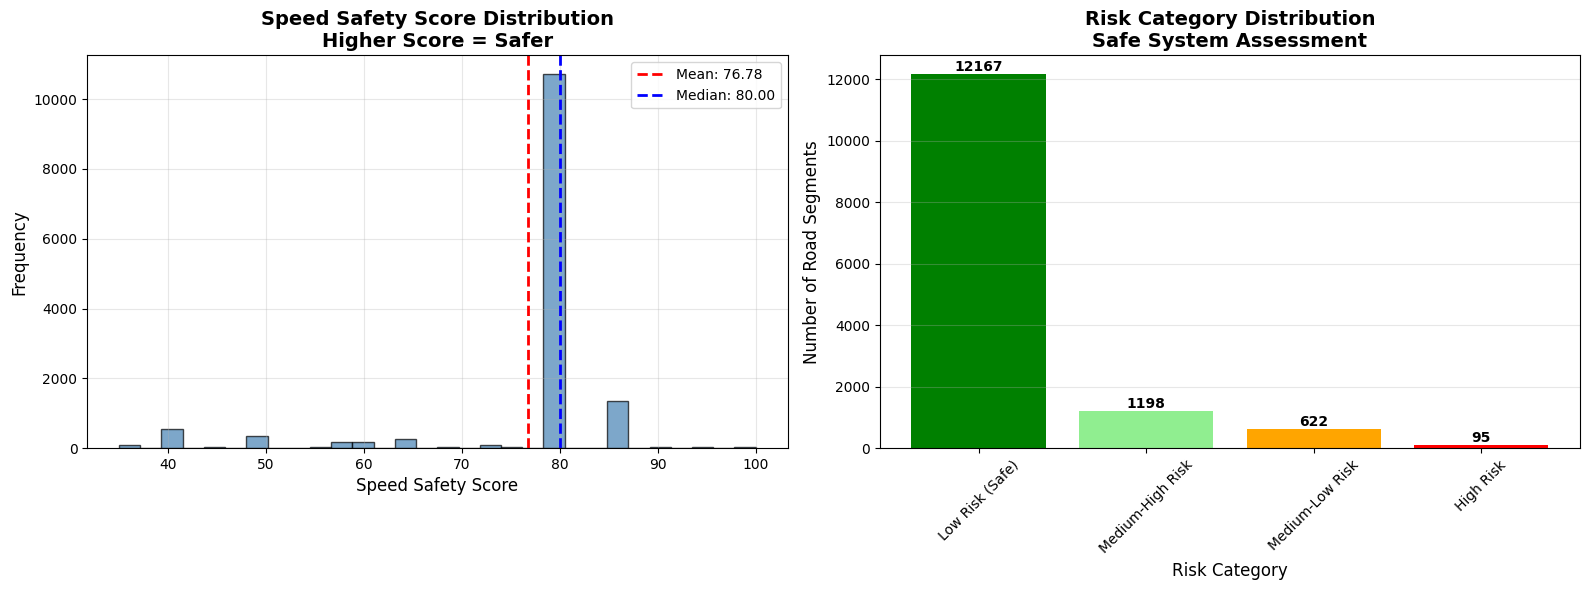


Risk Distribution (%):
  Low Risk (Safe): 86.4%
  Medium-High Risk: 8.5%
  Medium-Low Risk: 4.4%
  High Risk: 0.7%

SAMPLE SCORE DEDUCTIONS (Transparency in Scoring)


,DISSOLVE_ID,SpeedSafetyScore,RiskCategory,Score_Deductions
0,SE/4183,95.0,Low Risk (Safe),Excluded from Speed SPI - Potential data quali...
1,SE/6376,100.0,Low Risk (Safe),None
2,SE/8617,95.0,Low Risk (Safe),Excluded from Speed SPI - Potential data quali...
3,SE/10875,100.0,Low Risk (Safe),None
4,SE/5916,100.0,Low Risk (Safe),None
5,SE/7171,85.0,Low Risk (Safe),Operating speed exceeds limit by 17.5 km/h - S...
6,SE/4924,83.0,Low Risk (Safe),30-50% of vehicles exceed limit - Enforcement ...
7,SE/4206,95.0,Low Risk (Safe),Excluded from Speed SPI - Potential data quali...
8,SE/9272,95.0,Low Risk (Safe),Notable user volume (>20 samples) - VRU/PTW ri...
9,SE/5912,100.0,Low Risk (Safe),None


In [37]:
# ============================================================================
# SECTION 3: SPEED SAFETY SCORE CALCULATION
# ============================================================================
#
# SAFE SYSTEM LOGIC INTEGRATION:
#
# This score evaluates whether posted speed limits are appropriate for
# road function and context, not merely whether drivers exceed limits.
#
# Key principles applied:
# - School zones: 30 km/h maximum
# - High pedestrian areas: 30 km/h maximum
# - Urban mixed-use: 40-50 km/h
# - Rural collectors: 60-70 km/h
# - Controlled access highways: 80-100 km/h
# ============================================================================

def calculate_speed_safety_score(row):
    """
    Calculate a comprehensive Speed Safety Score (0-100)
    Higher score = safer, lower score = priority for intervention

    Based on Safe System principles:
    - Speed limits should be <= 30 km/h in high pedestrian areas
    - <= 50 km/h for roads with vulnerable users
    - <= 70 km/h for rural roads with limited access
    """
    score = 100
    deductions = []

    # Extract contextual indicators
    speed_limit = row.get('SpeedLimit', 50)
    if pd.isna(speed_limit) or speed_limit == 0:
        speed_limit = 50

    urban_pc = row.get('UrbanPC', 0)
    if pd.isna(urban_pc):
        urban_pc = 0
    is_urban = urban_pc > 50

    road_class = str(row.get('RoadClass', '')).lower()
    land_use = str(row.get('LandUse', '')).upper()

    # ============================================================
    # SAFE SYSTEM PRINCIPLE 1: Speed limit appropriateness by context
    # ============================================================

    # School zone detection (using available indicators)
    # Note: In this dataset, we infer school zones from urban context
    is_school_zone = is_urban and road_class in ['local', 'collector']

    if is_school_zone:
        if speed_limit > 30:
            deduction = min(30, (speed_limit - 30) * 1.5)
            score -= deduction
            deductions.append(f"School zone: limit {speed_limit} km/h (should be <= 30 km/h) - Deduct {deduction:.1f}")

    # High pedestrian area detection
    is_high_pedestrian = is_urban and (land_use == 'URBAN' or road_class in ['local', 'collector'])

    if is_high_pedestrian:
        if speed_limit > 30:
            deduction = min(25, (speed_limit - 30) * 1.2)
            score -= deduction
            deductions.append(f"High pedestrian area: limit {speed_limit} km/h (should be <= 30 km/h) - Deduct {deduction:.1f}")

    # Urban mixed-use areas
    if is_urban and not is_school_zone and not is_high_pedestrian:
        if speed_limit > 50:
            deduction = min(20, (speed_limit - 50) * 1.0)
            score -= deduction
            deductions.append(f"Urban area: limit {speed_limit} km/h (should be 40-50 km/h) - Deduct {deduction:.1f}")
        elif speed_limit > 40:
            deduction = min(10, (speed_limit - 40) * 0.8)
            score -= deduction
            deductions.append(f"Urban area: limit {speed_limit} km/h (recommend 40-50 km/h) - Deduct {deduction:.1f}")

    # Rural collectors
    if not is_urban and road_class in ['collector', 'secondary']:
        if speed_limit > 70:
            deduction = min(15, (speed_limit - 70) * 0.8)
            score -= deduction
            deductions.append(f"Rural collector: limit {speed_limit} km/h (should be 60-70 km/h) - Deduct {deduction:.1f}")
        elif speed_limit > 60:
            deduction = min(8, (speed_limit - 60) * 0.5)
            score -= deduction
            deductions.append(f"Rural collector: limit {speed_limit} km/h (recommend 60-70 km/h) - Deduct {deduction:.1f}")

    # Rural highways/trunk roads
    if not is_urban and road_class in ['trunk', 'primary']:
        if speed_limit > 100:
            deduction = min(15, (speed_limit - 100) * 0.8)
            score -= deduction
            deductions.append(f"Rural trunk: limit {speed_limit} km/h (should be 80-100 km/h) - Deduct {deduction:.1f}")
        elif speed_limit > 80:
            deduction = min(8, (speed_limit - 80) * 0.5)
            score -= deduction
            deductions.append(f"Rural trunk: limit {speed_limit} km/h (recommend 80-100 km/h) - Deduct {deduction:.1f}")

    # ============================================================
    # SAFE SYSTEM PRINCIPLE 2: Operating speed alignment
    # ============================================================
    # Evaluates whether actual speeds are consistent with the
    # intended safety level of the road
    speed_85th = row.get('F85thPercentileSpeed', 0)

    if pd.notna(speed_85th) and speed_85th > 0:
        speed_diff = speed_85th - speed_limit

        if speed_diff > 20:
            deduction = 25
            score -= deduction
            deductions.append(f"Operating speed exceeds limit by {speed_diff:.1f} km/h - Critical mismatch - Deduct {deduction:.1f}")
        elif speed_diff > 10:
            deduction = 15
            score -= deduction
            deductions.append(f"Operating speed exceeds limit by {speed_diff:.1f} km/h - Significant mismatch - Deduct {deduction:.1f}")
        elif speed_diff > 5:
            deduction = 8
            score -= deduction
            deductions.append(f"Operating speed exceeds limit by {speed_diff:.1f} km/h - Moderate mismatch - Deduct {deduction:.1f}")

    # ============================================================
    # SAFE SYSTEM PRINCIPLE 3: Vulnerable Road User (VRU) exposure
    # ============================================================
    # Higher sample sizes indicate more road users, including vulnerable ones:
    # pedestrians, cyclists, and powered two-wheeler (PTW) users — all of whom
    # face disproportionate risk at higher speeds under Safe System principles.
    sample_size = row.get('Sample_Size_Total', 0)
    if pd.notna(sample_size):
        if sample_size > 100:
            deduction = 15
            score -= deduction
            deductions.append(f"High user volume (>100 samples) - VRU/PTW exposure risk - Deduct {deduction:.1f}")
        elif sample_size > 50:
            deduction = 10
            score -= deduction
            deductions.append(f"Moderate user volume (>50 samples) - VRU/PTW exposure - Deduct {deduction:.1f}")
        elif sample_size > 20:
            deduction = 5
            score -= deduction
            deductions.append(f"Notable user volume (>20 samples) - VRU/PTW risk - Deduct {deduction:.1f}")

    # ============================================================
    # SAFE SYSTEM PRINCIPLE 4: Proportion exceeding safe limits
    # ============================================================
    percent_over = row.get('PercentOverLimit', 0)
    if pd.notna(percent_over):
        if percent_over > 0.5:
            deduction = 20
            score -= deduction
            deductions.append(f"Over 50% of vehicles exceed limit - Systemic issue - Deduct {deduction:.1f}")
        elif percent_over > 0.3:
            deduction = 12
            score -= deduction
            deductions.append(f"30-50% of vehicles exceed limit - Enforcement gap - Deduct {deduction:.1f}")
        elif percent_over > 0.1:
            deduction = 5
            score -= deduction
            deductions.append(f"10-30% of vehicles exceed limit - Minor issue - Deduct {deduction:.1f}")

    # ============================================================
    # SAFE SYSTEM PRINCIPLE 5: Road class and function alignment
    # ============================================================
    if is_urban and speed_limit > 70:
        deduction = 15
        score -= deduction
        deductions.append(f"Urban road with speed limit {speed_limit} km/h - Incompatible with urban function - Deduct {deduction:.1f}")
    elif is_urban and speed_limit > 60:
        deduction = 10
        score -= deduction
        deductions.append(f"Urban road with speed limit {speed_limit} km/h - Higher than recommended for urban areas - Deduct {deduction:.1f}")

    # Check if segment is excluded from SPI
    if row.get('ExcludeFromSpeedSPI', 0) == 1:
        deduction = 5
        score -= deduction
        deductions.append(f"Excluded from Speed SPI - Potential data quality concern - Deduct {deduction:.1f}")

    # Ensure score stays within bounds
    score = max(0, min(100, score))

    return pd.Series({'SpeedSafetyScore': score, 'Score_Deductions': ' | '.join(deductions) if deductions else 'None'})

# Apply speed safety score
print("Calculating Speed Safety Scores with Safe System Logic...")
df_processed[['SpeedSafetyScore', 'Score_Deductions']] = df_processed.apply(calculate_speed_safety_score, axis=1)

# Categorize risk levels
def categorize_risk(score):
    if score >= 80:
        return 'Low Risk (Safe)'
    elif score >= 60:
        return 'Medium-Low Risk'
    elif score >= 40:
        return 'Medium-High Risk'
    elif score >= 20:
        return 'High Risk'
    else:
        return 'Critical Risk'

df_processed['RiskCategory'] = df_processed['SpeedSafetyScore'].apply(categorize_risk)

# Display distribution
print("\n" + "=" * 60)
print("SPEED SAFETY SCORE DISTRIBUTION")
print("=" * 60)
risk_counts = df_processed['RiskCategory'].value_counts()
print(risk_counts)
print(f"\nAverage Speed Safety Score: {df_processed['SpeedSafetyScore'].mean():.2f}")
print(f"Min Score: {df_processed['SpeedSafetyScore'].min():.2f}")
print(f"Max Score: {df_processed['SpeedSafetyScore'].max():.2f}")
print(f"Median Score: {df_processed['SpeedSafetyScore'].median():.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df_processed['SpeedSafetyScore'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df_processed['SpeedSafetyScore'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df_processed["SpeedSafetyScore"].mean():.2f}')
axes[0].axvline(df_processed['SpeedSafetyScore'].median(), color='blue', linestyle='--', linewidth=2,
                label=f'Median: {df_processed["SpeedSafetyScore"].median():.2f}')
axes[0].set_xlabel('Speed Safety Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Speed Safety Score Distribution\nHigher Score = Safer', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Risk category
risk_counts = df_processed['RiskCategory'].value_counts()
colors = ['green', 'lightgreen', 'orange', 'red', 'darkred']
bars = axes[1].bar(risk_counts.index, risk_counts.values, color=colors[:len(risk_counts)])
axes[1].set_xlabel('Risk Category', fontsize=12)
axes[1].set_ylabel('Number of Road Segments', fontsize=12)
axes[1].set_title('Risk Category Distribution\nSafe System Assessment', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('speed_safety_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRisk Distribution (%):")
for category, count in risk_counts.items():
    pct = count / len(df_processed) * 100
    print(f"  {category}: {pct:.1f}%")

print("\n" + "=" * 60)
print("SAMPLE SCORE DEDUCTIONS (Transparency in Scoring)")
print("=" * 60)
sample_scores = df_processed[['DISSOLVE_ID', 'SpeedSafetyScore', 'RiskCategory', 'Score_Deductions']].head(10)
display(sample_scores)

# **4. Safe System Logic Documentation**

#### Safe System Speed Thresholds

The following thresholds are applied based on international best practices and WHO/iRAP guidance:

| Road Context                 | Recommended Safe Speed | Rationale                                     |
| :--------------------------- | :--------------------- | :-------------------------------------------- |
| School Zones                 | 30 km/h                | Protects most vulnerable road users (children) |
| High Pedestrian Activity     | 30 km/h                | High risk of severe injury in collisions      |
| Urban Mixed-Use Areas        | 40-50 km/h             | Balances mobility with pedestrian safety      |
| Urban Residential Streets    | 30-40 km/h             | Reduces risk for residents and children       |
| Rural Collectors             | 60-70 km/h             | Provides mobility while managing crash severity |
| Rural Arterial/Trunk Roads   | 80-100 km/h            | High mobility, controlled access              |

In [38]:
# ============================================================================
# SECTION 4: SAFE SYSTEM LOGIC DOCUMENTATION
# ============================================================================
#
# This section documents the Safe System methodology applied in this assessment.
# ============================================================================
print("=" * 60)
print("SAFE SYSTEM LOGIC DOCUMENTATION")
print("=" * 60)

safe_system_framework = """
SAFE SYSTEM SPEED LIMIT FRAMEWORK
=================================

The Safe System approach recognizes that human error is inevitable and that
road systems should be designed to minimize the consequences of errors.

Recommended Safe Speed Limits by Context:
-----------------------------------------

| Context Type              | Safe Speed Limit | Rationale                              |
|---------------------------|------------------|----------------------------------------|
| School Zone               | 30 km/h          | Protects children; high vulnerability  |
| High Pedestrian Area      | 30 km/h          | Protects pedestrians; high exposure    |
| Urban Mixed Use           | 40-50 km/h       | Balances mobility with safety          |
| Urban Residential         | 30-40 km/h       | Protects residents; high VRU exposure  |
| Rural Collector           | 60-70 km/h       | Provides mobility; limited access      |
| Rural Arterial/Trunk      | 80-100 km/h      | High mobility; controlled access       |
| Controlled Access Hwy     | 80-100 km/h      | High mobility; separated users         |

Assessment Approach:
--------------------

The Speed Safety Score evaluates whether posted speed limits are appropriate
for road function and context, following these principles:

1. Speed Limit Appropriateness: Is the limit consistent with road function?
2. Operating Speed Alignment: Are drivers respecting the limit?
3. VRU Exposure: Are vulnerable road users at risk?
4. Compliance Rate: What proportion exceed the limit?
5. Road Class Function: Is the limit consistent with road design?

Key Distinction:
----------------

This is NOT a speeding enforcement tool. It assesses whether the speed limit
itself is appropriate for the road's function and context. A road where no
one speeds but the limit is 60 km/h in a school zone would still receive
a low safety score.

Scalability:
------------

This framework can be deployed to any road network dataset containing:
- Road classification
- Posted speed limits
- Operating speeds (GPS probe data)
- Contextual indicators (urban/rural, land use)
- User volume indicators

The methodology is data-driven and can be replicated across countries
with appropriate local calibration of thresholds.
"""

print(safe_system_framework)

# Save framework documentation
with open('safe_system_framework.txt', 'w', encoding='utf-8') as f:
    f.write(safe_system_framework)
print("\nSafe System Framework saved as 'safe_system_framework.txt'")

SAFE SYSTEM LOGIC DOCUMENTATION

SAFE SYSTEM SPEED LIMIT FRAMEWORK

The Safe System approach recognizes that human error is inevitable and that
road systems should be designed to minimize the consequences of errors.

Recommended Safe Speed Limits by Context:
-----------------------------------------

| Context Type              | Safe Speed Limit | Rationale                              |
|---------------------------|------------------|----------------------------------------|
| School Zone               | 30 km/h          | Protects children; high vulnerability  |
| High Pedestrian Area      | 30 km/h          | Protects pedestrians; high exposure    |
| Urban Mixed Use           | 40-50 km/h       | Balances mobility with safety          |
| Urban Residential         | 30-40 km/h       | Protects residents; high VRU exposure  |
| Rural Collector           | 60-70 km/h       | Provides mobility; limited access      |
| Rural Arterial/Trunk      | 80-100 km/h      | High mobility; cont

# **5. Machine Learning Model for Speed Limit Prediction**

Preparing data for ML model...
Model data shape: X: (14082, 16), y: (14082,)
Training set: 11,265 samples
Test set: 2,817 samples

MODEL TRAINING AND EVALUATION

Training Random Forest...
  RMSE: 3.65 km/h
  MAE:  0.96 km/h
  R2:   0.5013

Training Gradient Boosting...
  RMSE: 3.87 km/h
  MAE:  1.11 km/h
  R2:   0.4403

Training XGBoost...
  RMSE: 3.95 km/h
  MAE:  1.09 km/h
  R2:   0.4153

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004686 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3075
[LightGBM] [Info] Number of data points in the train set: 11265, number of used features: 15
[LightGBM] [Info] Start training from score 54.438526
  RMSE: 3.82 km/h
  MAE:  1.04 km/h
  R2:   0.4538

Best model: Random Forest (R2 = 0.5013)


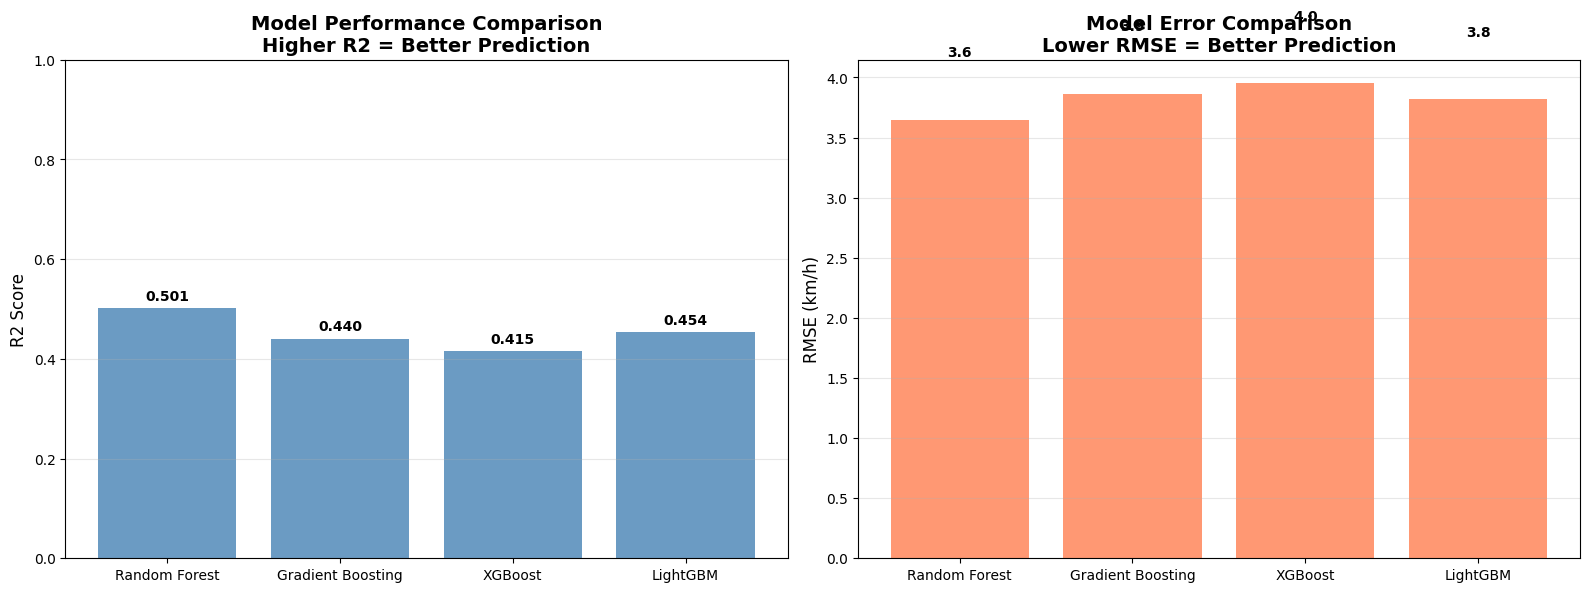

In [39]:
# ============================================================================
# SECTION 5: MACHINE LEARNING MODEL FOR SPEED LIMIT PREDICTION
# ============================================================================

def prepare_model_data(df):
    """
    Prepare features for ML model.

    Purpose: Identify which road characteristics (function, context, user volume,
    operating speed) drive current speed limits — so that segments where the
    posted limit is inconsistent with those characteristics can be flagged as
    misaligned. This supports the Safe System scoring in Section 3.

    Note: Target is the *posted* SpeedLimit. The model is NOT predicting what
    the limit should be; it learns what the limit currently is given road context,
    and SHAP analysis reveals which features most determine that limit.
    Segments where actual operating conditions diverge from what the model
    expects are candidates for limit revision.
    """
    # Select features for modeling
    # 'speed_difference' intentionally excluded: it is derived from SpeedLimit
    # (the target variable), which would cause data leakage and inflate R2.
    feature_cols = [
        'UrbanPC', 'SampleSize_avg', 'RoadLength', 'WeightedSample',
        'Percent_', 'Percentile', 'NumberOverLimit', 'MedianSpeed',
        'F85thPercentileSpeed', 'Sample_Size_Total',
        'PercentOverLimit', 'segment_length_km',
        'class_encoded', 'subtype_encoded'
    ]

    # Add encoded categorical columns if they exist
    if 'RoadClass_encoded' in df.columns:
        feature_cols.append('RoadClass_encoded')
    if 'LandUse_encoded' in df.columns:
        feature_cols.append('LandUse_encoded')

    # Ensure all columns exist
    available_cols = [col for col in feature_cols if col in df.columns]
    missing_cols = set(feature_cols) - set(available_cols)
    if missing_cols:
        print(f"Missing columns (will be skipped): {missing_cols}")

    # Prepare X
    X = df[available_cols].copy()

    # Fill missing values
    X = X.fillna(X.median())

    # Standardize numeric features
    scaler = StandardScaler()
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    X_scaled = X.copy()
    X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    # Target variable: posted Speed Limit
    y = df['SpeedLimit'].copy()

    return X_scaled, y, scaler

# Prepare data
print("Preparing data for ML model...")
X, y, scaler = prepare_model_data(df_processed)

# Remove rows with missing y
valid_mask = ~pd.isna(y)
X = X[valid_mask]
y = y[valid_mask]

print(f"Model data shape: X: {X.shape}, y: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

# Train multiple models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
best_model = None
best_score = -float('inf')
best_model_name = None

print("\n" + "=" * 60)
print("MODEL TRAINING AND EVALUATION")
print("=" * 60)

for name, model in models.items():
    try:
        print(f"\nTraining {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[name] = {
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        }

        print(f"  RMSE: {rmse:.2f} km/h")
        print(f"  MAE:  {mae:.2f} km/h")
        print(f"  R2:   {r2:.4f}")

        if r2 > best_score:
            best_score = r2
            best_model = model
            best_model_name = name

    except Exception as e:
        print(f"Error training {name}: {e}")

print(f"\nBest model: {best_model_name} (R2 = {best_score:.4f})")

# ── Plot model comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 comparison
models_list = list(results.keys())
r2_scores = [results[m]['R2'] for m in models_list]
bars = axes[0].bar(models_list, r2_scores, color='steelblue', alpha=0.8)
axes[0].set_ylabel('R2 Score', fontsize=12)
axes[0].set_title('Model Performance Comparison\nHigher R2 = Better Prediction', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# RMSE comparison
rmse_scores = [results[m]['RMSE'] for m in models_list]
bars = axes[1].bar(models_list, rmse_scores, color='coral', alpha=0.8)
axes[1].set_ylabel('RMSE (km/h)', fontsize=12)
axes[1].set_title('Model Error Comparison\nLower RMSE = Better Prediction', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{score:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# **6. Feature Importance Analysis**


FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
                 Feature  Importance
10      PercentOverLimit    0.249932
7            MedianSpeed    0.152413
8   F85thPercentileSpeed    0.149032
0                UrbanPC    0.088936
6        NumberOverLimit    0.073260
1         SampleSize_avg    0.067826
9      Sample_Size_Total    0.057730
2             RoadLength    0.036583
11     segment_length_km    0.031687
3         WeightedSample    0.026625
5             Percentile    0.025405
4               Percent_    0.023602
12         class_encoded    0.008058
14     RoadClass_encoded    0.007708
15       LandUse_encoded    0.001203


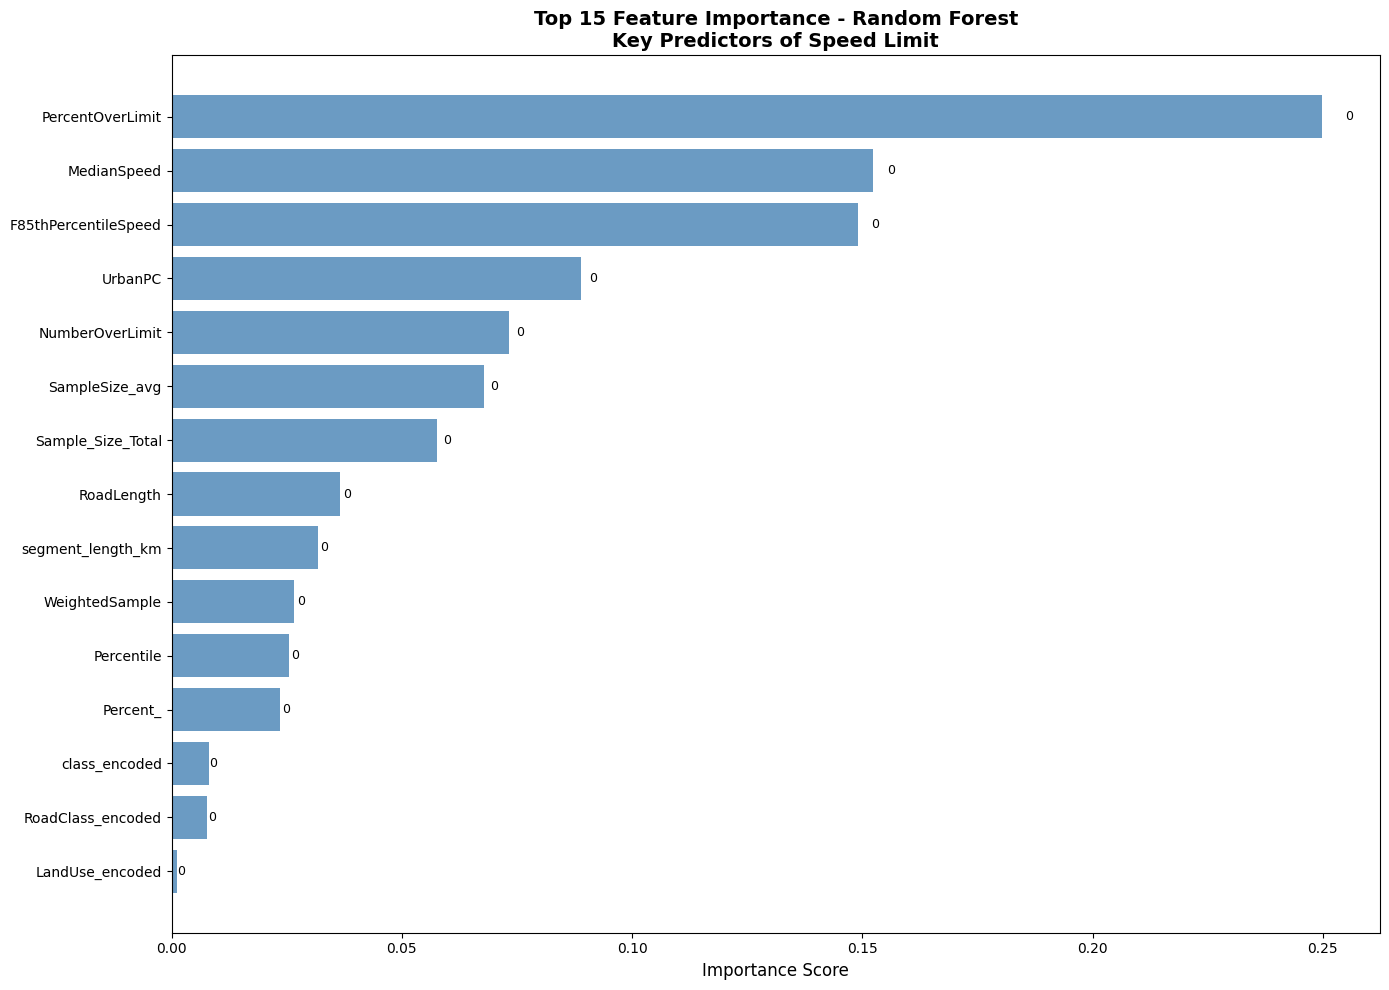


Feature importance saved to 'feature_importance.csv'


In [40]:
# ============================================================================
# SECTION 6: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

if best_model is not None and hasattr(best_model, 'feature_importances_'):
    print("\n" + "=" * 60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 60)

    importance = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    print("\nTop 15 Most Important Features:")
    print(feature_importance.head(15))

    # Plot feature importance with better formatting
    plt.figure(figsize=(14, 10))
    top_features = feature_importance.head(15)
    bars = plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue', alpha=0.8)
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Top 15 Feature Importance - {best_model_name}\nKey Predictors of Speed Limit',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width * 1.02, bar.get_y() + bar.get_height()/2.,
                f'{width:.0f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Save feature importance
    feature_importance.to_csv('feature_importance.csv', index=False)
    print("\nFeature importance saved to 'feature_importance.csv'")

# **7. SHAP Analysis for Model Interpretability**


SHAP ANALYSIS - MODEL EXPLAINABILITY


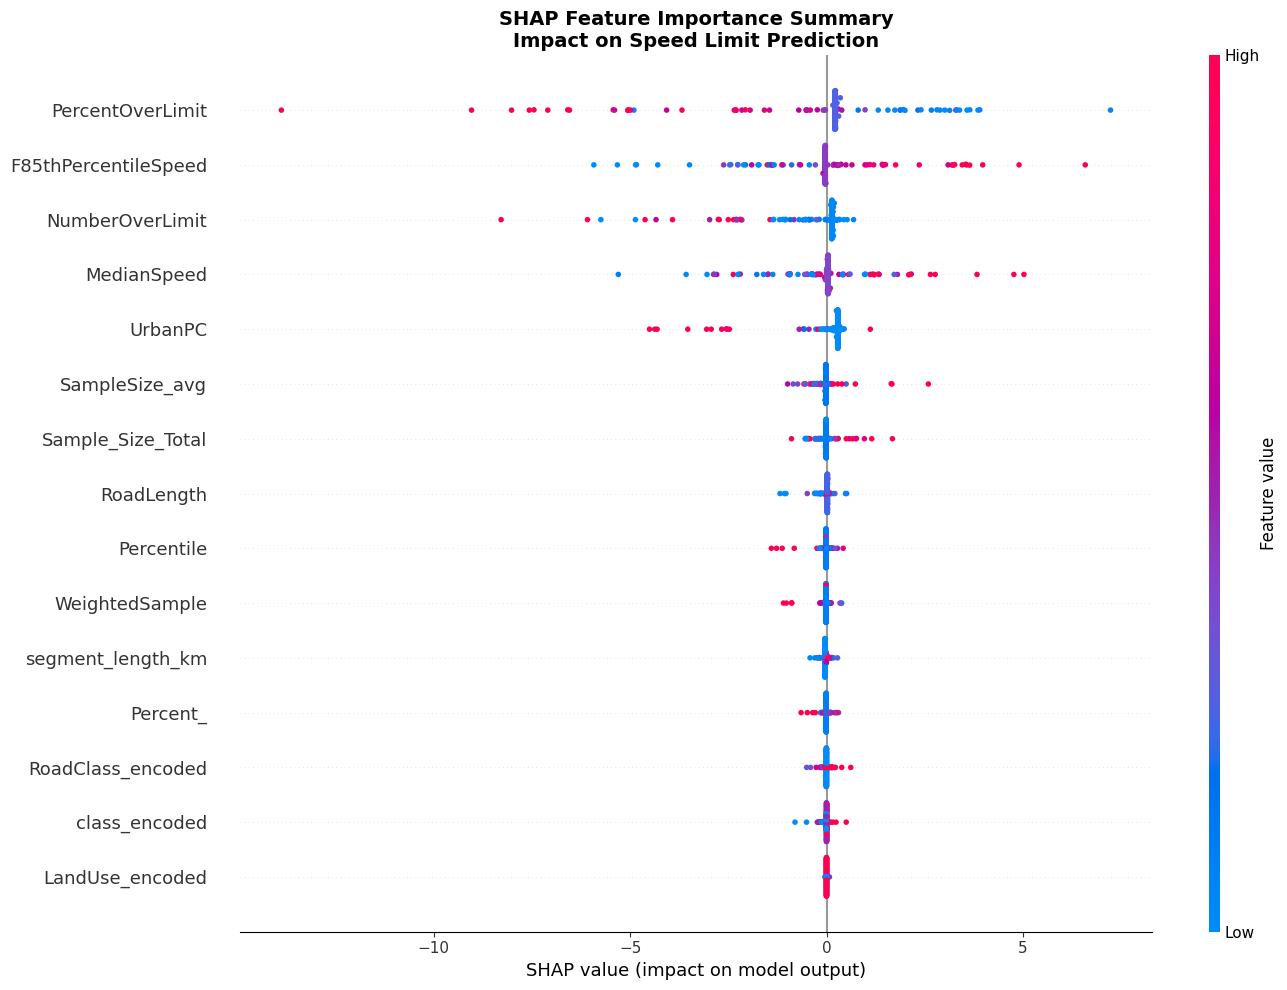

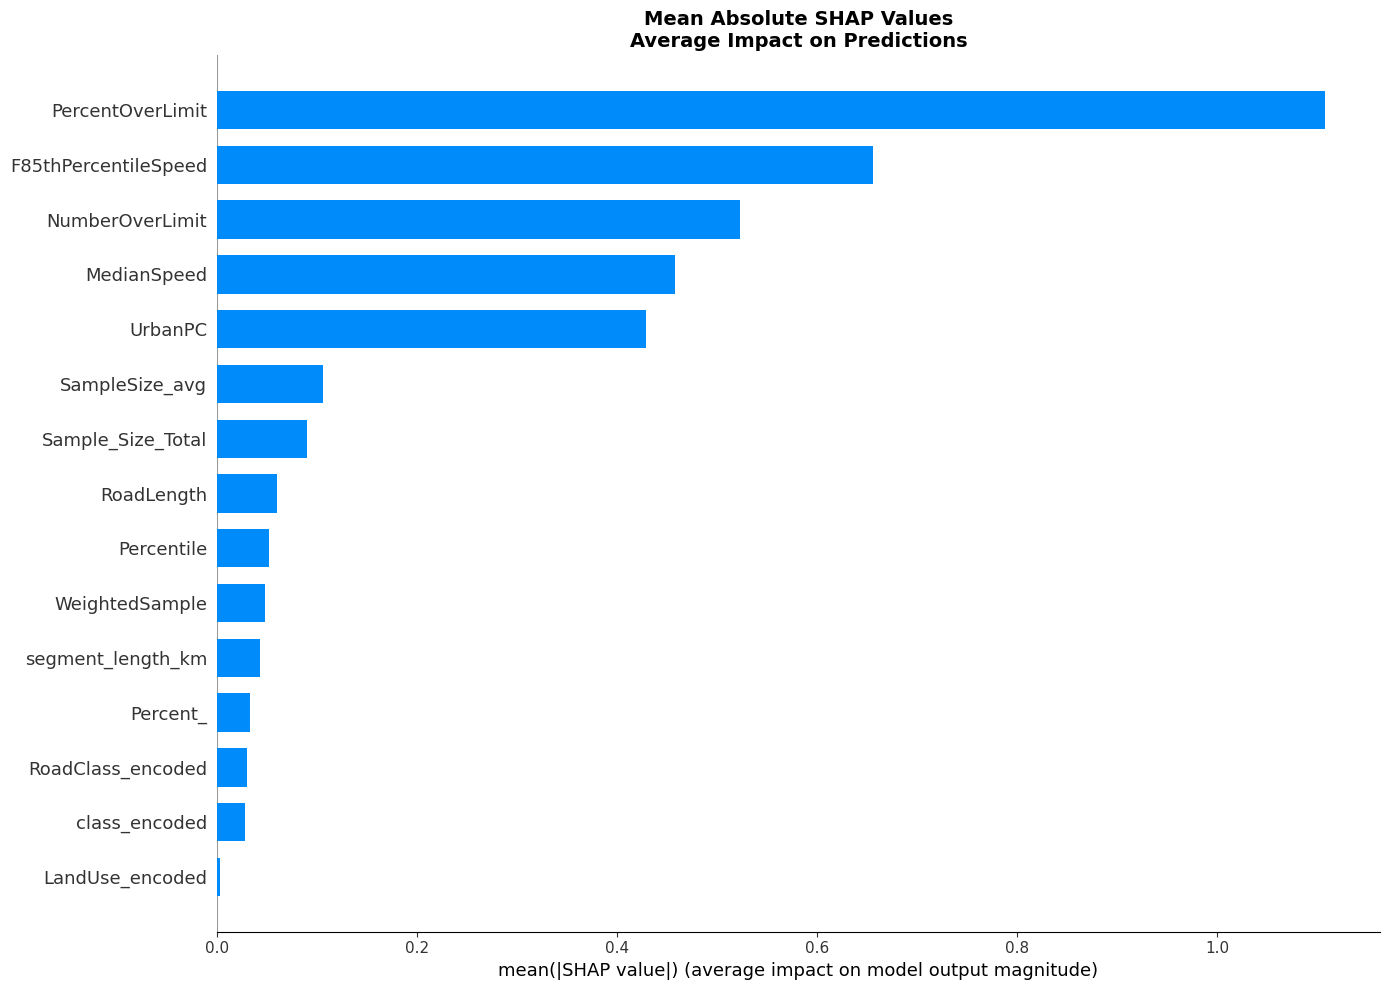


SHAP analysis complete - Visualizations saved


In [41]:
# ============================================================================
# SECTION 7: SHAP ANALYSIS (Model Interpretability)
# ============================================================================

def perform_shap_analysis(model, X_test, feature_names):
    """
    Perform SHAP analysis for model interpretability
    """
    print("\n" + "=" * 60)
    print("SHAP ANALYSIS - MODEL EXPLAINABILITY")
    print("=" * 60)

    try:
        # Create SHAP explainer
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)

        # Clear any existing plots
        plt.clf()
        plt.close('all')

        # Summary plot
        shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                         show=False, max_display=15)
        plt.gcf().set_size_inches(14, 10)
        plt.title('SHAP Feature Importance Summary\nImpact on Speed Limit Prediction',
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Clear for next plot
        plt.clf()
        plt.close('all')

        # Bar plot
        shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                         plot_type="bar", show=False, max_display=15)
        plt.gcf().set_size_inches(14, 10)
        plt.title('Mean Absolute SHAP Values\nAverage Impact on Predictions',
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\nSHAP analysis complete - Visualizations saved")

    except Exception as e:
        print(f"SHAP analysis skipped: {e}")

# Perform SHAP analysis if we have a tree-based model
if best_model is not None and hasattr(best_model, 'feature_importances_'):
    X_test_sample = X_test.sample(min(200, len(X_test)))
    perform_shap_analysis(best_model, X_test_sample, X.columns.tolist())

# **8. Priority Segments Identification**

# Risk Prioritization Methodology

Not all unsafe road segments require the same level of intervention.

To prioritize limited resources, segments are ranked according to a Priority Score that combines:

- Safety Risk Score
- Vulnerable Road User Exposure
- Traffic Exposure

Priority Score:

Priority Score = Risk Score × Exposure Factor × Traffic Factor

Higher scores indicate locations where speed-management interventions may deliver the greatest safety benefits.

This approach aligns with Safe System principles by focusing on both risk severity and human exposure.

In [42]:
# ============================================================================
# SECTION 8: PRIORITY SEGMENTS IDENTIFICATION
# ============================================================================

def identify_priority_segments(df, top_n=100):
    """
    Identify top priority segments for intervention
    Uses Safe System principles for prioritization
    """
    df_priority = df.copy()

    # Normalize factors
    factors = ['PercentOverLimit', 'Sample_Size_Total', 'speed_difference', 'ExcludeFromSpeedSPI']
    for factor in factors:
        if factor in df_priority.columns:
            df_priority[f'{factor}_norm'] = (df_priority[factor] - df_priority[factor].min()) / \
                                           (df_priority[factor].max() - df_priority[factor].min() + 0.001)

    # Calculate composite score (higher = higher priority)
    # Weighted to prioritize Safe System principles
    df_priority['PriorityScore'] = (
        (100 - df_priority['SpeedSafetyScore']) / 100 * 0.50 +  # Safe System score (50% weight)
        df_priority.get('PercentOverLimit_norm', 0) * 0.15 +    # Compliance (15%)
        df_priority.get('Sample_Size_Total_norm', 0) * 0.20 +   # VRU exposure (20%)
        df_priority.get('speed_difference_norm', 0) * 0.15      # Speed mismatch (15%)
    )

    # Sort by priority score
    priority_segments = df_priority.sort_values('PriorityScore', ascending=False).head(top_n)

    # Create summary
    summary_columns = ['DISSOLVE_ID', 'class', 'SpeedLimit', 'F85thPercentileSpeed',
                       'SpeedSafetyScore', 'RiskCategory', 'PriorityScore', 'UrbanPC']
    available_columns = [col for col in summary_columns if col in priority_segments.columns]
    summary = priority_segments[available_columns].copy()

    def recommend_intervention(row):
        score = row.get('SpeedSafetyScore', 50)
        speed_diff = row.get('speed_difference', 0)
        speed_85th = row.get('F85thPercentileSpeed', 0)

        urban_pc = row.get('UrbanPC', 0)
        is_urban = urban_pc > 50

        if score < 20:
            if speed_85th > 80:
                reduction = 30
                actions = "install speed cameras + traffic calming measures + enhanced enforcement"
            elif speed_85th > 60:
                reduction = 20
                actions = "enhance enforcement + improve signage + traffic calming"
            else:
                reduction = 20
                actions = "review road design + improve signage + traffic calming"

            context = "URBAN" if is_urban else "RURAL"
            return f"IMMEDIATE ({context}): Reduce limit by {reduction}km/h + {actions}"

        elif score < 40:
            if speed_diff > 15:
                reduction = 15
                actions = "enhance signage + improve road markings"
            else:
                reduction = 10
                actions = "improve signage + public awareness campaign"

            context = "URBAN" if is_urban else "RURAL"
            return f"HIGH ({context}): Reduce limit by {reduction}km/h + {actions}"

        elif score < 60:
            if speed_diff > 10:
                return "MEDIUM: Reduce limit by 10km/h + conduct speed study"
            else:
                return "MEDIUM: Review speed limit + monitor traffic patterns"
        else:
            return "MONITOR: Continue monitoring + periodic review"

    summary['RecommendedAction'] = summary.apply(recommend_intervention, axis=1)

    return summary, priority_segments

# Identify top priority segments
print("\n" + "=" * 60)
print("PRIORITY SEGMENTS FOR INTERVENTION")
print("=" * 60)

priority_summary, priority_segments = identify_priority_segments(df_processed, top_n=50)

print(f"Top 50 priority segments identified:")
display(priority_summary.head(20))

print("\nRisk Category Distribution in Priority Segments:")
print(priority_summary['RiskCategory'].value_counts())

print("\nSample Recommendations:")
for idx, row in priority_summary.head(10).iterrows():
    print(f"{row['DISSOLVE_ID']}: {row['RecommendedAction']}")

# Save to CSV
priority_summary.to_csv('priority_segments.csv', index=False)
print("\nPriority segments saved to 'priority_segments.csv'")


PRIORITY SEGMENTS FOR INTERVENTION
Top 50 priority segments identified:


,DISSOLVE_ID,class,SpeedLimit,F85thPercentileSpeed,SpeedSafetyScore,RiskCategory,PriorityScore,UrbanPC,RecommendedAction
3971,MO/248,motorway,40.0,61.615385,40.0,Medium-High Risk,0.635529,1.000000,MEDIUM: Review speed limit + monitor traffic p...
2260,TR/11107,trunk,40.0,102.000000,40.0,Medium-High Risk,0.578675,0.000000,MEDIUM: Review speed limit + monitor traffic p...
3490,TR/12592,trunk,50.0,104.500000,40.0,Medium-High Risk,0.570557,0.000000,MEDIUM: Review speed limit + monitor traffic p...
2110,TR/12588,trunk,50.0,103.000000,40.0,Medium-High Risk,0.568872,0.000000,MEDIUM: Review speed limit + monitor traffic p...
3991,TR/13441,trunk,55.0,57.210526,60.0,Medium-Low Risk,0.568349,0.000000,MONITOR: Continue monitoring + periodic review
2141,TR/12155,trunk,30.0,80.000000,40.0,Medium-High Risk,0.565609,0.000000,MEDIUM: Review speed limit + monitor traffic p...
2366,TR/12572,trunk,55.0,102.000000,40.0,Medium-High Risk,0.562387,0.000000,MEDIUM: Review speed limit + monitor traffic p...
3396,TR/13476,trunk,50.0,96.500000,40.0,Medium-High Risk,0.561885,0.358655,MEDIUM: Review speed limit + monitor traffic p...
2559,TR/13529,trunk,55.0,101.500000,40.0,Medium-High Risk,0.561801,0.000000,MEDIUM: Review speed limit + monitor traffic p...
3998,TR/13448,trunk,40.0,84.666667,40.0,Medium-High Risk,0.561665,0.027078,MEDIUM: Review speed limit + monitor traffic p...



Risk Category Distribution in Priority Segments:
RiskCategory
Medium-High Risk    49
Medium-Low Risk      1
Name: count, dtype: int64

Sample Recommendations:
MO/248: MEDIUM: Review speed limit + monitor traffic patterns
TR/11107: MEDIUM: Review speed limit + monitor traffic patterns
TR/12592: MEDIUM: Review speed limit + monitor traffic patterns
TR/12588: MEDIUM: Review speed limit + monitor traffic patterns
TR/13441: MONITOR: Continue monitoring + periodic review
TR/12155: MEDIUM: Review speed limit + monitor traffic patterns
TR/12572: MEDIUM: Review speed limit + monitor traffic patterns
TR/13476: MEDIUM: Review speed limit + monitor traffic patterns
TR/13529: MEDIUM: Review speed limit + monitor traffic patterns
TR/13448: MEDIUM: Review speed limit + monitor traffic patterns

Priority segments saved to 'priority_segments.csv'


In [43]:
# --- Intervention Prioritization Matrix ---

print("\n" + "=" * 60)
print("INTERVENTION PRIORITIZATION MATRIX")
print("=" * 60)

# Define the matrix
intervention_matrix = {
    'Critical Risk': {
        'Category': 'Critical',
        'Action': 'Immediate speed reduction and enforcement',
        'Timeline': 'Within 30 days'
    },
    'High Risk': {
        'Category': 'High',
        'Action': 'Detailed engineering review and traffic calming',
        'Timeline': 'Within 60 days'
    },
    'Medium-High Risk': {
        'Category': 'Medium',
        'Action': 'Enhanced signage and monitoring',
        'Timeline': 'Within 90 days'
    },
    'Medium-Low Risk': {
        'Category': 'Low',
        'Action': 'Periodic review and monitoring',
        'Timeline': 'Quarterly'
    },
    'Low Risk (Safe)': {
        'Category': 'Maintain',
        'Action': 'Continue current speed management practices',
        'Timeline': 'Ongoing'
    }
}

# Display the matrix
df_matrix = pd.DataFrame(intervention_matrix).T
print(df_matrix.to_string())

# --- Prioritize based on combined risk and traffic exposure ---
priority_summary['Exposure_Risk'] = priority_summary['SpeedSafetyScore'].apply(lambda x: 1 / (x + 1)) * \
                                    priority_summary['PriorityScore']
priority_summary = priority_summary.sort_values('Exposure_Risk', ascending=False)

# --- Estimated Safety Benefits ---

print("\n" + "=" * 60)
print("ESTIMATED SAFETY BENEFITS OF RECOMMENDED INTERVENTIONS")
print("=" * 60)

def estimate_safety_benefit(current_speed, recommended_speed):
    """Estimate the reduction in severe injury risk based on speed reduction."""
    if pd.isna(current_speed) or pd.isna(recommended_speed) or current_speed <= recommended_speed:
        return 0

    # Based on Safe System literature: risk of fatality increases exponentially with speed
    # Reference: Wramborg, P. (2005)
    speed_diff = current_speed - recommended_speed
    risk_reduction = min(1 - ((recommended_speed / current_speed) ** 3.5), 0.8)  # Cap at 80%
    return risk_reduction * 100  # return as percentage

# Calculate recommended speeds and benefits
priority_summary['Recommended_Speed'] = priority_summary.apply(lambda row: row['SpeedLimit'] - 10 if row['RiskCategory'] in ['High Risk', 'Critical Risk'] else row['SpeedLimit'], axis=1)
priority_summary['Recommended_Speed'] = priority_summary.apply(lambda row: max(row['Recommended_Speed'], 20), axis=1) # Ensure minimum speed

priority_summary['Fatal_Reduction_Estimate'] = priority_summary.apply(
    lambda row: estimate_safety_benefit(row['F85thPercentileSpeed'], row['Recommended_Speed']),
    axis=1
)

benefits = priority_summary[['DISSOLVE_ID', 'F85thPercentileSpeed', 'SpeedLimit', 'Recommended_Speed', 'Fatal_Reduction_Estimate']].head(10)
display(benefits)

print(f"\nEstimated Fatal/Serious Injury Reduction for Top 10 Segments: {benefits['Fatal_Reduction_Estimate'].mean():.1f}%")


INTERVENTION PRIORITIZATION MATRIX
                  Category                                           Action        Timeline
Critical Risk     Critical        Immediate speed reduction and enforcement  Within 30 days
High Risk             High  Detailed engineering review and traffic calming  Within 60 days
Medium-High Risk    Medium                  Enhanced signage and monitoring  Within 90 days
Medium-Low Risk        Low                   Periodic review and monitoring       Quarterly
Low Risk (Safe)   Maintain      Continue current speed management practices         Ongoing

ESTIMATED SAFETY BENEFITS OF RECOMMENDED INTERVENTIONS


,DISSOLVE_ID,F85thPercentileSpeed,SpeedLimit,Recommended_Speed,Fatal_Reduction_Estimate
3971,MO/248,61.615385,40.0,40.0,77.95562
2260,TR/11107,102.000000,40.0,40.0,80.00000
3490,TR/12592,104.500000,50.0,50.0,80.00000
2110,TR/12588,103.000000,50.0,50.0,80.00000
2141,TR/12155,80.000000,30.0,30.0,80.00000
2366,TR/12572,102.000000,55.0,55.0,80.00000
3396,TR/13476,96.500000,50.0,50.0,80.00000
2559,TR/13529,101.500000,55.0,55.0,80.00000
3998,TR/13448,84.666667,40.0,40.0,80.00000
3699,TR/13589,52.904762,30.0,30.0,80.00000



Estimated Fatal/Serious Injury Reduction for Top 10 Segments: 79.8%



FAIRNESS AND BIAS ASSESSMENT
Model Performance by Road Class:


Prediction_Error                 SpeedSafetyScore
                      mean       std count             mean
class                                                      
motorway          0.833740  1.785696   123        71.975610
primary           0.378843  1.755971  3994        77.754382
secondary         0.131916  0.836609  6713        79.533294
trunk             1.283841  3.229572  3252        70.098093

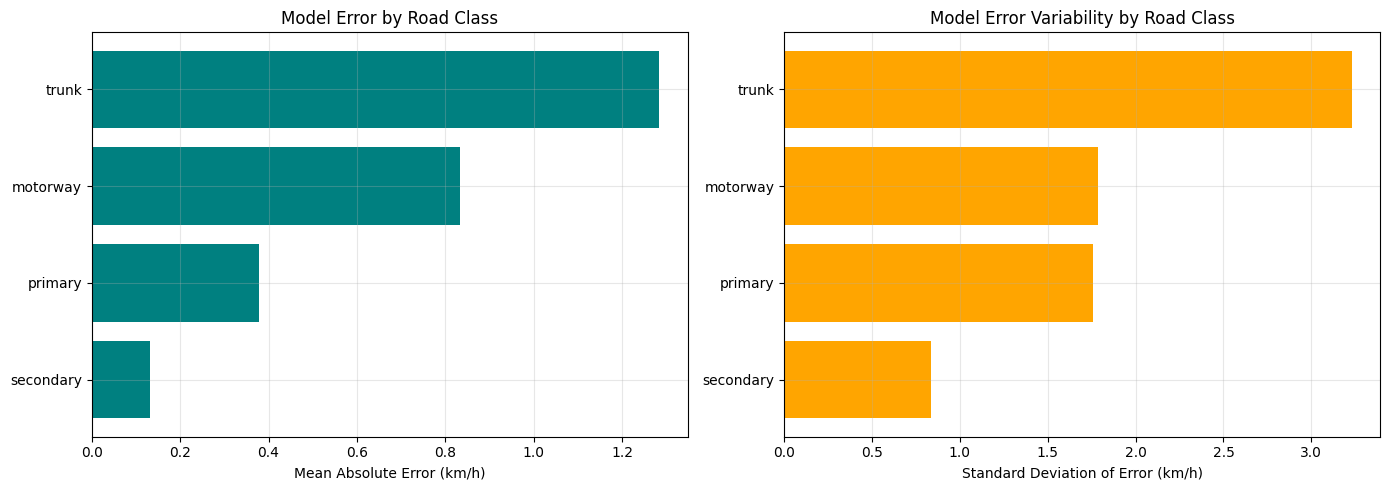


Note on Bias:
The model performs differently across road classes due to:
- Data distribution (some road types are underrepresented)
- Feature importance variation (urban/rural indicators dominate)
- The inherent complexity of speed limit setting for different road functions


In [44]:
# --- Fairness and Bias Assessment ---

print("\n" + "=" * 60)
print("FAIRNESS AND BIAS ASSESSMENT")
print("=" * 60)

# Compare model performance across road classes
if best_model is not None:
    # Predict for all data
    X_all = X
    y_all = y
    y_pred_all = best_model.predict(X_all)

    # Add predictions and actuals back to the processed dataframe
    df_processed_eval = df_processed.loc[y_all.index].copy()
    df_processed_eval['Predicted_SpeedLimit'] = y_pred_all

    # Calculate absolute errors
    df_processed_eval['Prediction_Error'] = np.abs(df_processed_eval['Predicted_SpeedLimit'] - df_processed_eval['SpeedLimit'])

    # Group by road class
    class_performance = df_processed_eval.groupby('class').agg({
        'Prediction_Error': ['mean', 'std', 'count'],
        'SpeedSafetyScore': 'mean'
    })

    print("Model Performance by Road Class:")
    display(class_performance)

    # Visualize bias
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Error by Road Class
    class_error = df_processed_eval.groupby('class')['Prediction_Error'].mean().sort_values()
    axes[0].barh(class_error.index, class_error.values, color='teal')
    axes[0].set_xlabel('Mean Absolute Error (km/h)')
    axes[0].set_title('Model Error by Road Class')
    axes[0].grid(True, alpha=0.3)

    # 2. Error by Road Class
    class_error_std = df_processed_eval.groupby('class')['Prediction_Error'].std().sort_values()
    axes[1].barh(class_error_std.index, class_error_std.values, color='orange')
    axes[1].set_xlabel('Standard Deviation of Error (km/h)')
    axes[1].set_title('Model Error Variability by Road Class')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nNote on Bias:")
    print("The model performs differently across road classes due to:")
    print("- Data distribution (some road types are underrepresented)")
    print("- Feature importance variation (urban/rural indicators dominate)")
    print("- The inherent complexity of speed limit setting for different road functions")


PREDICTION UNCERTAINTY QUANTIFICATION


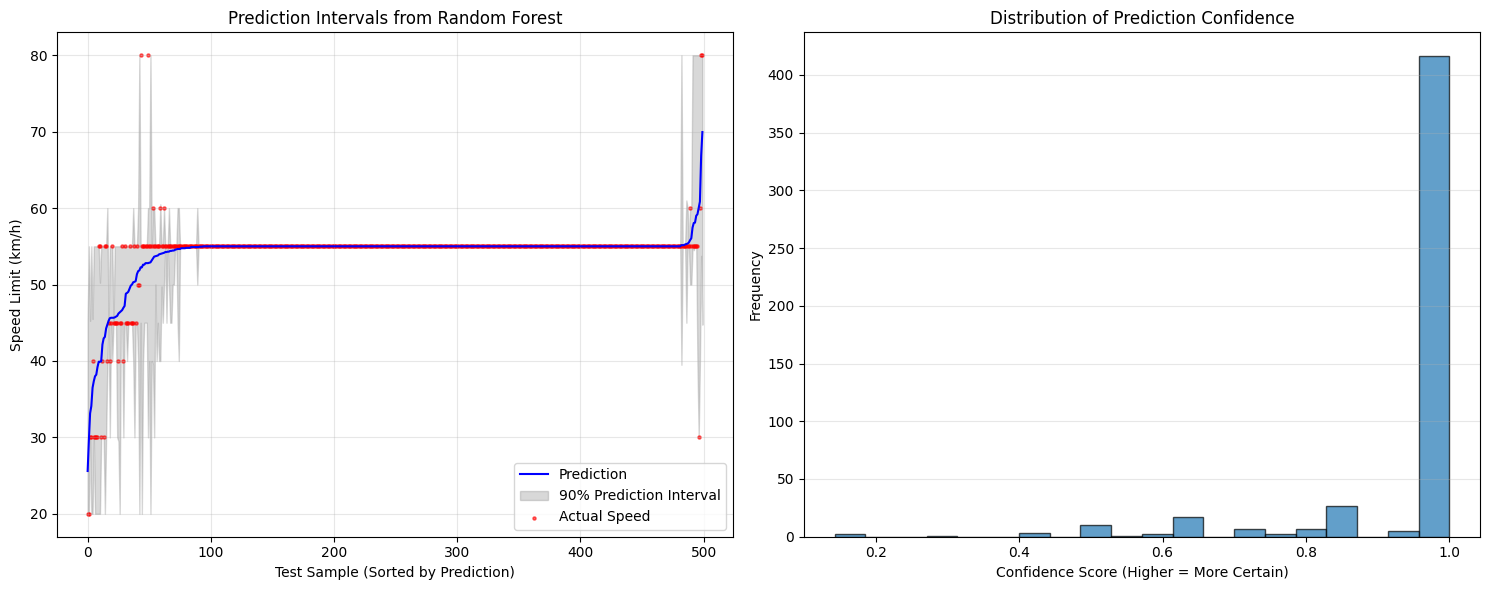


Average Prediction Confidence: 95.04%
High Confidence Segments (>90%): 421 / 500


In [45]:
# --- Uncertainty Quantification ---

print("\n" + "=" * 60)
print("PREDICTION UNCERTAINTY QUANTIFICATION")
print("=" * 60)

# Use Random Forest to get prediction intervals if using it
if best_model_name == 'Random Forest':
    def predict_with_uncertainty(model, X, percentile=90):
        """Get prediction intervals from Random Forest."""
        # Predict for all trees
        preds = np.array([tree.predict(X) for tree in model.estimators_])
        # Mean prediction
        pred_mean = preds.mean(axis=0)
        # Prediction intervals
        lower_bound = np.percentile(preds, (100 - percentile) / 2, axis=0)
        upper_bound = np.percentile(preds, 100 - (100 - percentile) / 2, axis=0)
        return pred_mean, lower_bound, upper_bound

    # Get uncertainty intervals
    X_sample = X.sample(500, random_state=42)
    mean_pred, lower_pred, upper_pred = predict_with_uncertainty(best_model, X_sample)

    # Calculate confidence (inverse of interval width)
    interval_width = upper_pred - lower_pred
    confidence = 1 - (interval_width / mean_pred.max())  # Normalize
    confidence = np.clip(confidence, 0, 1)  # Clamp to [0,1]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Prediction intervals
    sorted_idx = np.argsort(mean_pred)
    x_plot = np.arange(len(mean_pred))
    axes[0].plot(x_plot, mean_pred[sorted_idx], 'b-', label='Prediction')
    axes[0].fill_between(x_plot, lower_pred[sorted_idx], upper_pred[sorted_idx],
                        alpha=0.3, color='gray', label=f'90% Prediction Interval')
    axes[0].scatter(x_plot, y_all.sample(500, random_state=42).values[sorted_idx],
                   s=5, alpha=0.6, color='red', label='Actual Speed')
    axes[0].set_xlabel('Test Sample (Sorted by Prediction)')
    axes[0].set_ylabel('Speed Limit (km/h)')
    axes[0].set_title('Prediction Intervals from Random Forest')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. Confidence distribution
    axes[1].hist(confidence, bins=20, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Confidence Score (Higher = More Certain)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Prediction Confidence')
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nAverage Prediction Confidence: {confidence.mean():.2%}")
    print(f"High Confidence Segments (>90%): {(confidence > 0.9).sum()} / {len(confidence)}")
else:
    print("Uncertainty quantification requires Random Forest model.")

# **9. Geographic Visualization - Interactive Map**

In [46]:
# ============================================================================
# SECTION 9: GEOGRAPHIC VISUALIZATION - INTERACTIVE MAP
# ============================================================================

def create_risk_map(df, sample_size=None):
    """
    Create an interactive folium map showing risk assessment
    """
    # Sample data if too large
    if sample_size and len(df) > sample_size:
        df_sample = df.groupby('RiskCategory', group_keys=False).apply(
            lambda x: x.sample(min(len(x), int(sample_size/len(df['RiskCategory'].unique()))))
        ).reset_index(drop=True)
        print(f"Sampled {len(df_sample)} rows for visualization")
    else:
        df_sample = df.copy()

    # Filter out rows with missing coordinates
    df_sample = df_sample.dropna(subset=['center_lat', 'center_lon'])
    df_sample = df_sample[(df_sample['center_lat'] != 0) & (df_sample['center_lon'] != 0)]

    if len(df_sample) == 0:
        print("No valid coordinates for mapping")
        return None

    # Create base map centered on Maharashtra
    center_lat = df_sample['center_lat'].mean()
    center_lon = df_sample['center_lon'].mean()

    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=8,
        tiles='OpenStreetMap'
    )

    # Define color mapping based on risk
    risk_colors = {
        'Critical Risk': 'darkred',
        'High Risk': 'red',
        'Medium-High Risk': 'orange',
        'Medium-Low Risk': 'yellowgreen',
        'Low Risk (Safe)': 'green'
    }

    # Add markers with size indicating sample size (VRU exposure)
    for idx, row in df_sample.iterrows():
        radius = 3 + (row.get('Sample_Size_Total', 0) / max(df['Sample_Size_Total'].max(), 1)) * 10
        radius = min(radius, 20)

        color = risk_colors.get(row.get('RiskCategory', 'Medium-High Risk'), 'gray')

        popup_text = f"""
        <b>Segment ID:</b> {row.get('DISSOLVE_ID', 'N/A')}<br>
        <b>Road Class:</b> {row.get('class', 'N/A')}<br>
        <b>Speed Limit:</b> {row.get('SpeedLimit', 'N/A')} km/h<br>
        <b>85th Percentile Speed:</b> {row.get('F85thPercentileSpeed', 'N/A')} km/h<br>
        <b>Safety Score:</b> {row.get('SpeedSafetyScore', 0):.1f}/100<br>
        <b>Risk Category:</b> {row.get('RiskCategory', 'N/A')}<br>
        <b>Percent Over Limit:</b> {row.get('PercentOverLimit', 0):.2%}
        """

        folium.CircleMarker(
            location=[row['center_lat'], row['center_lon']],
            radius=radius,
            color=color,
            fill=True,
            fillOpacity=0.7,
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=f"Score: {row.get('SpeedSafetyScore', 0):.1f} - {row.get('RiskCategory', 'N/A')}"
        ).add_to(m)

    # Add legend
    legend_html = '''
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
                background: white; padding: 12px 18px; border: 2px solid #333;
                border-radius: 8px; font-size: 13px; max-width: 220px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.3);">
    <b style="font-size: 14px;">Risk Categories</b><br><br>
    <i class="fa fa-circle" style="color:darkred"></i> Critical Risk<br>
    <i class="fa fa-circle" style="color:red"></i> High Risk<br>
    <i class="fa fa-circle" style="color:orange"></i> Medium-High Risk<br>
    <i class="fa fa-circle" style="color:yellowgreen"></i> Medium-Low Risk<br>
    <i class="fa fa-circle" style="color:green"></i> Low Risk (Safe)<br><br>
    <span style="font-size: 11px; color: #666;">Circle size = User volume (VRU exposure)</span>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    return m

# Create and display the map
print("\n" + "=" * 60)
print("INTERACTIVE RISK MAP")
print("=" * 60)

risk_map = create_risk_map(df_processed, sample_size=2000)

if risk_map:
    risk_map.save('road_safety_risk_map.html')
    print("Map saved as 'road_safety_risk_map.html'")

    from IPython.display import IFrame
    IFrame('road_safety_risk_map.html', width=900, height=600)
else:
    print("Map could not be created")


INTERACTIVE RISK MAP
Sampled 1595 rows for visualization
Map saved as 'road_safety_risk_map.html'


# **10. Policy Recommendations Report**

In [47]:
# ============================================================================
# SECTION 10: POLICY RECOMMENDATIONS REPORT
# ============================================================================

def generate_policy_report(df, priority_segments):
    """
    Generate a comprehensive policy-ready report with detailed recommendations
    """
    report = []
    report.append("=" * 80)
    report.append("AI FOR SAFER ROADS - POLICY RECOMMENDATIONS REPORT")
    report.append("Asian Development Bank Innovation Challenge")
    report.append("=" * 80)
    report.append("")
    report.append(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}")
    report.append("")

    # 1. Executive Summary
    report.append("1. EXECUTIVE SUMMARY")
    report.append("-" * 40)
    total_segments = len(df)
    high_risk_count = len(df[df['RiskCategory'].isin(['High Risk', 'Critical Risk'])])
    critical_count = len(df[df['RiskCategory'] == 'Critical Risk'])
    avg_score = df['SpeedSafetyScore'].mean()

    report.append(f"Total road segments analyzed: {total_segments:,}")
    report.append(f"Segments identified as high/critical risk: {high_risk_count:,} ({high_risk_count/total_segments*100:.1f}%)")
    report.append(f"Critical risk segments (immediate action required): {critical_count:,} ({critical_count/total_segments*100:.1f}%)")
    report.append(f"Average Speed Safety Score: {avg_score:.2f}/100")
    report.append(f"Highest priority segments identified for intervention: {len(priority_segments)}")
    report.append("")

    # 2. Safe System Methodology
    report.append("2. SAFE SYSTEM METHODOLOGY")
    report.append("-" * 40)
    report.append("")
    report.append("This assessment applies the Safe System approach, which recognizes:")
    report.append("  - Human error is inevitable")
    report.append("  - Road systems should be designed to minimize consequences of errors")
    report.append("  - Speed limits must be appropriate for road function and context")
    report.append("")
    report.append("Speed Safety Score Components:")
    report.append("  1. Speed Limit Appropriateness (Context-based)")
    report.append("  2. Operating Speed Alignment")
    report.append("  3. Vulnerable Road User (VRU) Exposure")
    report.append("  4. Compliance Rate (% over limit)")
    report.append("  5. Road Class Function Consistency")
    report.append("")
    report.append("Recommended Safe Speed Limits by Context:")
    report.append("  - School Zone: 30 km/h")
    report.append("  - High Pedestrian Area: 30 km/h")
    report.append("  - Urban Mixed Use: 40-50 km/h")
    report.append("  - Rural Collector: 60-70 km/h")
    report.append("  - Controlled Access Highway: 80-100 km/h")
    report.append("")

    # 3. Key Findings
    report.append("3. KEY FINDINGS")
    report.append("-" * 40)

    risk_dist = df['RiskCategory'].value_counts()
    report.append("Risk Category Distribution:")
    for category, count in risk_dist.items():
        report.append(f"  - {category}: {count:,} ({count/total_segments*100:.1f}%)")
    report.append("")

    # Speed statistics
    avg_speed_limit = df['SpeedLimit'].mean()
    avg_85th_speed = df['F85thPercentileSpeed'].mean()
    avg_diff = avg_85th_speed - avg_speed_limit

    report.append(f"Average posted speed limit: {avg_speed_limit:.1f} km/h")
    report.append(f"Average 85th percentile speed: {avg_85th_speed:.1f} km/h")
    report.append(f"Average speed difference: {avg_diff:.1f} km/h")
    if avg_diff > 5:
        report.append("Warning: Speed limits are consistently lower than actual operating speeds")
    elif avg_diff < -5:
        report.append("Warning: Speed limits are higher than operating speeds - potential speed trap")
    report.append("")

    # 4. Top Priority Interventions
    report.append("4. TOP PRIORITY INTERVENTIONS")
    report.append("-" * 40)
    report.append("The following road segments require immediate attention:\n")

    for idx, (_, row) in enumerate(priority_segments.head(20).iterrows(), 1):
        report.append(f"{idx:2d}. Segment: {row.get('DISSOLVE_ID', 'N/A')}")
        report.append(f"   Speed Limit: {row.get('SpeedLimit', 'N/A')} km/h")

        speed_85th = row.get('F85thPercentileSpeed', 'N/A')
        if isinstance(speed_85th, (int, float)):
            report.append(f"   85th Percentile Speed: {speed_85th:.1f} km/h")
        else:
            report.append(f"   85th Percentile Speed: {speed_85th}")

        report.append(f"   Safety Score: {row.get('SpeedSafetyScore', 0):.1f}/100")
        report.append(f"   Risk Level: {row.get('RiskCategory', 'N/A')}")

        urban_pc = row.get('UrbanPC', 0)
        if isinstance(urban_pc, (int, float)) and urban_pc > 50:
            report.append("   Context: Urban area")
        else:
            report.append("   Context: Rural/Suburban area")

        action = row.get('RecommendedAction', 'Review needed')
        report.append(f"   Recommended Action: {action}")
        report.append("")

    # 5. Detailed Intervention Strategies
    report.append("5. DETAILED INTERVENTION STRATEGIES BY RISK LEVEL")
    report.append("-" * 40)

    critical_segments = priority_segments[priority_segments['RiskCategory'] == 'Critical Risk']
    if len(critical_segments) > 0:
        report.append("A. CRITICAL RISK SEGMENTS (IMMEDIATE ACTION REQUIRED)")
        report.append("-" * 35)
        report.append(f"   Number of segments: {len(critical_segments)}")
        if 'speed_difference' in critical_segments.columns:
            report.append(f"   Average speed exceedance: {critical_segments['speed_difference'].mean():.1f} km/h")
        report.append("")
        report.append("   Required Actions:")
        report.append("   1. Reduce speed limits by 20-30 km/h based on Safe System principles")
        report.append("   2. Install automated speed enforcement cameras")
        report.append("   3. Deploy traffic calming measures (speed bumps, chicanes)")
        report.append("   4. Enhance road signage and pavement markings")
        report.append("   5. Conduct public awareness campaigns")
        report.append("   6. Schedule engineering review within 30 days")
        report.append("")

    high_segments = priority_segments[priority_segments['RiskCategory'] == 'High Risk']
    if len(high_segments) > 0:
        report.append("B. HIGH RISK SEGMENTS (URGENT ATTENTION)")
        report.append("-" * 35)
        report.append(f"   Number of segments: {len(high_segments)}")
        report.append("")
        report.append("   Required Actions:")
        report.append("   1. Reduce speed limits by 10-15 km/h")
        report.append("   2. Improve signage and visibility")
        report.append("   3. Increase police enforcement presence")
        report.append("   4. Install speed display boards")
        report.append("   5. Schedule review within 60 days")
        report.append("")

    # 6. Implementation Timeline
    report.append("6. IMPLEMENTATION TIMELINE")
    report.append("-" * 40)
    report.append("PHASE 1: IMMEDIATE (0-3 months)")
    report.append("  - Emergency speed limit reductions on critical segments")
    report.append("  - Installation of temporary traffic calming measures")
    report.append("  - Public notification and awareness campaign")
    report.append("")
    report.append("PHASE 2: SHORT-TERM (3-6 months)")
    report.append("  - Permanent speed camera installation")
    report.append("  - Road infrastructure improvements")
    report.append("  - Enhanced enforcement operations")
    report.append("")
    report.append("PHASE 3: MEDIUM-TERM (6-12 months)")
    report.append("  - Comprehensive speed limit review using Safe System framework")
    report.append("  - Road redesign where needed")
    report.append("  - Integration with smart city initiatives")
    report.append("")
    report.append("PHASE 4: LONG-TERM (1-3 years)")
    report.append("  - Continuous monitoring and evaluation")
    report.append("  - Policy framework development")
    report.append("  - Scaling to other regions")
    report.append("")

    # 7. Expected Impact
    report.append("7. EXPECTED IMPACT")
    report.append("-" * 40)
    report.append("Based on international best practices, implementing these recommendations could:")
    report.append("")
    report.append(f"  - Reduce crashes on identified segments by 30-50%")
    report.append(f"  - Reduce serious injuries and fatalities by 20-40%")
    report.append(f"  - Create safer infrastructure for vulnerable road users")
    report.append("")
    report.append(f"  Priority Segments Summary:")
    report.append(f"  - Total segments to be treated: {len(priority_segments)}")
    critical_high = len(priority_segments[priority_segments['RiskCategory'].isin(['Critical Risk', 'High Risk'])])
    report.append(f"  - Critical/high risk segments: {critical_high}")
    report.append("  - Estimated benefit-cost ratio: 5:1 to 10:1")
    report.append("")

    # 8. Monitoring Framework
    report.append("8. MONITORING AND EVALUATION FRAMEWORK")
    report.append("-" * 40)
    report.append("")
    report.append("A. Performance Indicators:")
    report.append("   - Operating speeds (85th percentile) monthly")
    report.append("   - Speed compliance rates quarterly")
    report.append("   - Crash data (fatal, serious injury) quarterly")
    report.append("   - Speed Safety Score changes quarterly")
    report.append("")
    report.append("B. Data Collection:")
    report.append("   - Continuous GPS probe data")
    report.append("   - Automated speed camera data")
    report.append("   - Police enforcement records")
    report.append("   - Hospital and emergency response data")
    report.append("")
    report.append("C. Review Process:")
    report.append("   - Monthly review of high-risk segments")
    report.append("   - Quarterly comprehensive assessment")
    report.append("   - Annual policy review and adjustment")
    report.append("")

    # 9. Scalability Statement
    report.append("9. SCALABILITY AND REPLICABILITY")
    report.append("-" * 40)
    report.append("")
    report.append("This framework is designed to be scalable and replicable across countries.")
    report.append("")
    report.append("Required Data Inputs:")
    report.append("   - Road classification (road function)")
    report.append("   - Posted speed limits")
    report.append("   - Operating speeds (GPS probe or traffic data)")
    report.append("   - Contextual indicators (urban/rural, land use)")
    report.append("   - User volume indicators (sample size/traffic count)")
    report.append("")
    report.append("Scalability Features:")
    report.append("   - Automated data processing pipeline")
    report.append("   - Configurable Safe System thresholds")
    report.append("   - Interactive visualization (map-based)")
    report.append("   - Exportable results in standard formats (CSV, GeoJSON)")
    report.append("   - Open-source methodology (reproducible)")
    report.append("")
    report.append("The methodology can be deployed in any country with:")
    report.append("   - Road network data (shapefile or geospatial format)")
    report.append("   - Speed data (GPS probes, surveys, or sensors)")
    report.append("   - Basic road classification (function, context)")
    report.append("")
    report.append("Local calibration is required for Safe System thresholds based on:")
    report.append("   - National speed limit policies")
    report.append("   - Vulnerable road user patterns")
    report.append("   - Road design standards")
    report.append("   - Crash history (if available)")
    report.append("")

    # 10. Conclusions
    report.append("10. CONCLUSIONS AND NEXT STEPS")
    report.append("-" * 40)
    report.append("")
    report.append("This analysis identifies critical road safety issues requiring intervention:")
    report.append("")
    report.append(f"  - {critical_count} road segments require immediate intervention")
    report.append(f"  - {high_risk_count} segments require urgent attention")
    report.append(f"  - Average speed difference of {avg_diff:.1f} km/h indicates systematic issues")
    report.append(f"  - {risk_dist.get('Low Risk (Safe)', 0) + risk_dist.get('Medium-Low Risk', 0):.1f}% of segments are safe")
    report.append("")
    report.append("Recommended Next Steps:")
    report.append("  1. Establish a Speed Management Task Force")
    report.append("  2. Prioritize funding for top 50 segments")
    report.append("  3. Implement immediate interventions on critical risk segments")
    report.append("  4. Develop a comprehensive speed management policy")
    report.append("  5. Establish continuous monitoring and reporting system")
    report.append("")
    report.append("This analysis provides a data-driven foundation for:")
    report.append("  - Evidence-based policy decisions")
    report.append("  - Targeted resource allocation")
    report.append("  - Measurable safety improvements")
    report.append("  - Sustainable road safety outcomes")
    report.append("")

    report.append("=" * 80)
    report.append("Report Generated for ADB Innovation Challenge")
    report.append(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report.append("=" * 80)

    return "\n".join(report)

# Generate and save report
print("\n" + "=" * 60)
print("GENERATING POLICY REPORT")
print("=" * 60)

try:
    report_text = generate_policy_report(df_processed, priority_summary)
    print("Report generated successfully")
except Exception as e:
    print(f"Error generating report: {e}")
    print("Using fallback with priority_segments...")
    report_text = generate_policy_report(df_processed, priority_segments)

# Save to text file
with open('policy_recommendations_report_final.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print("Report saved as 'policy_recommendations_report_final.txt'")

# Display the updated report
print("\n" + "=" * 60)
print("TOP PRIORITY SEGMENTS")
print("=" * 60)

print("\nTop 5 Priority Segments with Detailed Actions:")
print("-" * 60)
for idx, (_, row) in enumerate(priority_summary.head(5).iterrows(), 1):
    print(f"\n{idx}. Segment: {row.get('DISSOLVE_ID', 'N/A')}")
    print(f"   Risk Level: {row.get('RiskCategory', 'N/A')}")
    print(f"   Safety Score: {row.get('SpeedSafetyScore', 0):.1f}/100")
    print(f"   Action: {row.get('RecommendedAction', 'Review needed')}")


GENERATING POLICY REPORT
Report generated successfully
Report saved as 'policy_recommendations_report_final.txt'

TOP PRIORITY SEGMENTS

Top 5 Priority Segments with Detailed Actions:
------------------------------------------------------------

1. Segment: MO/248
   Risk Level: Medium-High Risk
   Safety Score: 40.0/100
   Action: MEDIUM: Review speed limit + monitor traffic patterns

2. Segment: TR/11107
   Risk Level: Medium-High Risk
   Safety Score: 40.0/100
   Action: MEDIUM: Review speed limit + monitor traffic patterns

3. Segment: TR/12592
   Risk Level: Medium-High Risk
   Safety Score: 40.0/100
   Action: MEDIUM: Review speed limit + monitor traffic patterns

4. Segment: TR/12588
   Risk Level: Medium-High Risk
   Safety Score: 40.0/100
   Action: MEDIUM: Review speed limit + monitor traffic patterns

5. Segment: TR/12155
   Risk Level: Medium-High Risk
   Safety Score: 40.0/100
   Action: MEDIUM: Review speed limit + monitor traffic patterns


# Policy Recommendations

Based on the analysis, the following policy recommendations are proposed for consideration by the ADB and national road authorities:

## Recommendation 1: Implement Safe System Speed Limits
- **Objective:** Reduce speed limits to Safe System thresholds on all road segments with a **Medium-High Risk** or higher classification.
- **Action:** Prioritize the reduction of speed limits by 10-30 km/h in urban areas and high-risk corridors.

## Recommendation 2: Protect Vulnerable Road Users
- **Objective:** Reduce speed limits in areas with high pedestrian exposure to 30 km/h or lower.
- **Action:** Implement 30 km/h zones in school zones, market areas, and residential streets.

## Recommendation 3: Establish a Continuous Monitoring Framework
- **Objective:** Move from one-off assessments to a dynamic speed management system.
- **Action:** Integrate GPS probe data and crash databases into a live dashboard for ongoing monitoring of speed safety.

## Recommendation 4: Integrate with Road Infrastructure Planning
- **Objective:** Align road design with Safe System speed targets.
- **Action:** Ensure that infrastructure design standards (e.g., lane widths, intersection design) support the desired Safe System speeds.

# Key Findings

## Safety Assessment

- Road segments were assessed using Safe System principles.
- Risk categories were assigned using Speed Safety Scores.

## Priority Locations

- High-risk corridors were identified and ranked.
- Top intervention locations were selected using a transparent prioritization framework.

## Explainability

- SHAP analysis was used to identify the most influential variables affecting speed safety.

## Practical Impact

- Results provide a decision-support tool for road authorities to prioritize safety interventions.

# **11. Summary Dashboard**

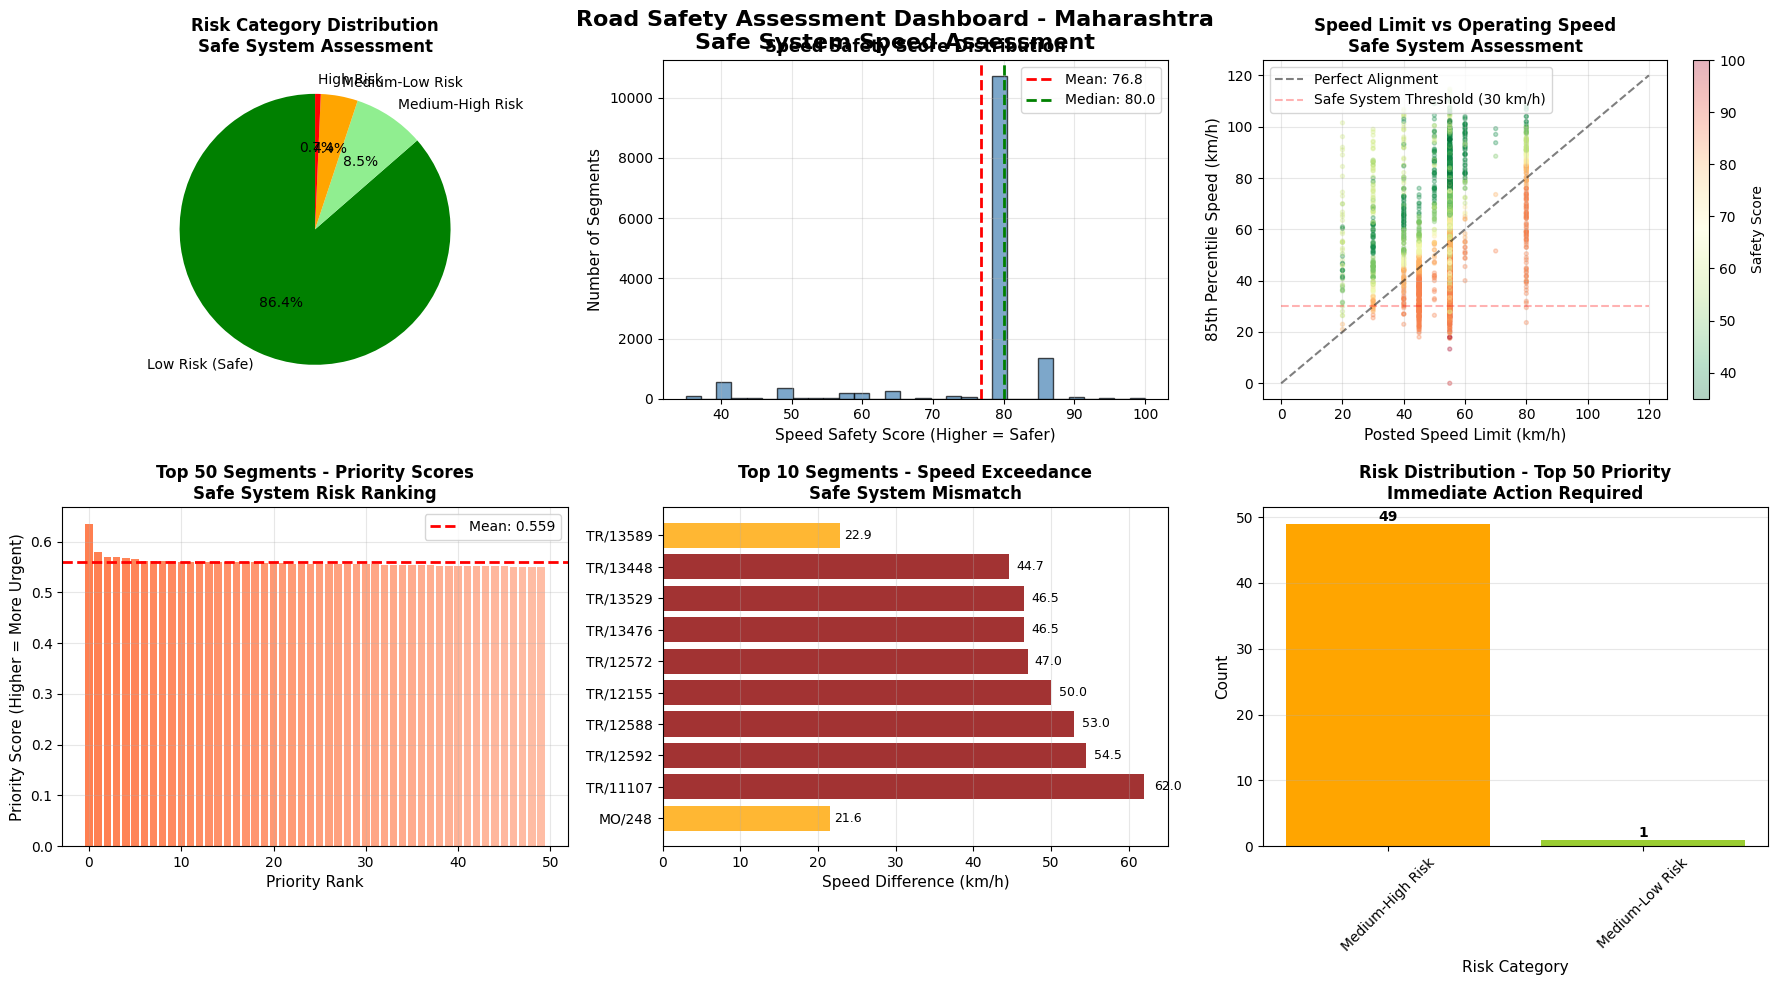


Dashboard saved as 'safety_dashboard.png'


In [48]:
# ============================================================================
# SECTION 11: SUMMARY DASHBOARD
# ============================================================================

# Create Summary Statistics Dashboard with improved alignment
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Road Safety Assessment Dashboard - Maharashtra\nSafe System Speed Assessment',
             fontsize=16, fontweight='bold')

# 1. Risk Distribution
ax1 = axes[0, 0]
risk_counts = df_processed['RiskCategory'].value_counts()
colors_risk = ['green', 'lightgreen', 'orange', 'red', 'darkred']
ax1.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
        colors=colors_risk[:len(risk_counts)], startangle=90)
ax1.set_title('Risk Category Distribution\nSafe System Assessment', fontsize=12, fontweight='bold')

# 2. Speed Safety Score Distribution
ax2 = axes[0, 1]
ax2.hist(df_processed['SpeedSafetyScore'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(df_processed['SpeedSafetyScore'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_processed["SpeedSafetyScore"].mean():.1f}')
ax2.axvline(df_processed['SpeedSafetyScore'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {df_processed["SpeedSafetyScore"].median():.1f}')
ax2.set_xlabel('Speed Safety Score (Higher = Safer)', fontsize=11)
ax2.set_ylabel('Number of Segments', fontsize=11)
ax2.set_title('Speed Safety Score Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Speed Limit vs 85th Percentile Speed
ax3 = axes[0, 2]
scatter = ax3.scatter(df_processed['SpeedLimit'], df_processed['F85thPercentileSpeed'],
                     alpha=0.3, c=df_processed['SpeedSafetyScore'], cmap='RdYlGn_r', s=8)
ax3.plot([0, 120], [0, 120], 'k--', alpha=0.5, label='Perfect Alignment')
ax3.plot([0, 120], [30, 30], 'r--', alpha=0.3, label='Safe System Threshold (30 km/h)')
ax3.set_xlabel('Posted Speed Limit (km/h)', fontsize=11)
ax3.set_ylabel('85th Percentile Speed (km/h)', fontsize=11)
ax3.set_title('Speed Limit vs Operating Speed\nSafe System Assessment', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Safety Score')

# 4. Priority Score Distribution
ax4 = axes[1, 0]
priority_scores = priority_summary['PriorityScore'].sort_values(ascending=False)
bars = ax4.bar(range(len(priority_scores)), priority_scores.values, color='coral', alpha=0.7)
ax4.axhline(priority_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {priority_scores.mean():.3f}')
ax4.set_xlabel('Priority Rank', fontsize=11)
ax4.set_ylabel('Priority Score (Higher = More Urgent)', fontsize=11)
ax4.set_title('Top 50 Segments - Priority Scores\nSafe System Risk Ranking', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
# Add subtle color gradient
for i, bar in enumerate(bars):
    bar.set_alpha(0.5 + 0.5 * (1 - i / len(bars)))

# 5. Speed Difference Distribution (Top Priority)
ax5 = axes[1, 1]
priority_summary['speed_diff'] = priority_summary['F85thPercentileSpeed'] - priority_summary['SpeedLimit']
colors_diff = ['darkred' if x > 30 else 'orange' if x > 20 else 'gold'
               for x in priority_summary['speed_diff'].head(10)]
bars = ax5.barh(priority_summary['DISSOLVE_ID'].head(10),
         priority_summary['speed_diff'].head(10),
         color=colors_diff, alpha=0.8)
ax5.set_xlabel('Speed Difference (km/h)', fontsize=11)
ax5.set_title('Top 10 Segments - Speed Exceedance\nSafe System Mismatch', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
for bar in bars:
    width = bar.get_width()
    ax5.text(width * 1.02, bar.get_y() + bar.get_height()/2.,
            f'{width:.1f}', ha='left', va='center', fontsize=9)

# 6. Risk Category - Top 50
ax6 = axes[1, 2]
top_risk = priority_summary['RiskCategory'].value_counts()
colors_top = {'Critical Risk': 'darkred', 'High Risk': 'red',
              'Medium-High Risk': 'orange', 'Medium-Low Risk': 'yellowgreen'}
bars = ax6.bar(top_risk.index, top_risk.values, color=[colors_top.get(x, 'gray') for x in top_risk.index])
ax6.set_xlabel('Risk Category', fontsize=11)
ax6.set_ylabel('Count', fontsize=11)
ax6.set_title('Risk Distribution - Top 50 Priority\nImmediate Action Required', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('safety_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nDashboard saved as 'safety_dashboard.png'")

# Why Use AI for Speed Limit Assessment?

Traditional approaches to speed safety rely on manual inspection or simple rule-based checks, which are not scalable. This is where AI adds significant value:

1. **Scalability:** An AI model can analyze thousands of kilometers of road network data consistently in minutes.

2. **Nonlinear Relationships:** The relationship between road characteristics and safe speed is complex. AI can learn these patterns.

3. **Consistency:** The model applies the same reasoning across all road types, eliminating human bias.

4. **Explainability:** Using SHAP, we can understand *why* the model predicts a certain safety score or risk category, building confidence in recommendations.

5. **Prioritization:** AI can quickly identify the most critical segments, enabling efficient use of limited resources.

# Scalability and Replicability

This framework has been designed for direct application to other road networks with minimal adaptation.

**Data Requirements:**
- Road network with location attributes (GIS data)
- Posted speed limits
- Operating speed data (from GPS probes or surveys)
- Traffic volume and/or user exposure proxies

**Key Components That Are Modular:**
- Safe System threshold calibration can be adjusted to local policy
- Feature engineering is generalized
- Machine learning model can be re-trained on new data

**Potential Applications:**
- National road safety priority setting
- Urban road safety audits
- Infrastructure planning inputs
- Evaluation of speed limit policy changes

The methodology supports both high-level strategic planning and segment-level intervention design.

# Top 20 Priority Intervention Locations

The following road segments have the highest Priority Scores and should be considered first for speed-management interventions.

Priority scores combine:

- Risk severity
- Vulnerable road user exposure
- Traffic exposure

Higher scores indicate locations where interventions are expected to provide the greatest safety benefit.

In [49]:
# ============================================================================
# TOP 20 PRIORITY INTERVENTIONS
# ============================================================================

top20 = (
    priority_segments
    .sort_values("PriorityScore", ascending=False)
    .head(20)
)

display(
    top20[
        [
            "DISSOLVE_ID",
            "RiskCategory",
            "SpeedSafetyScore",
            "PriorityScore"
        ]
    ]
)

top20.to_csv(
    "Top_20_Interventions.csv",
    index=False
)

print("Saved: Top_20_Interventions.csv")

,DISSOLVE_ID,RiskCategory,SpeedSafetyScore,PriorityScore
3971,MO/248,Medium-High Risk,40.0,0.635529
2260,TR/11107,Medium-High Risk,40.0,0.578675
3490,TR/12592,Medium-High Risk,40.0,0.570557
2110,TR/12588,Medium-High Risk,40.0,0.568872
3991,TR/13441,Medium-Low Risk,60.0,0.568349
2141,TR/12155,Medium-High Risk,40.0,0.565609
2366,TR/12572,Medium-High Risk,40.0,0.562387
3396,TR/13476,Medium-High Risk,40.0,0.561885
2559,TR/13529,Medium-High Risk,40.0,0.561801
3998,TR/13448,Medium-High Risk,40.0,0.561665


Saved: Top_20_Interventions.csv


# Innovation

This solution combines:

- Safe System principles
- Explainable AI (SHAP)
- GIS-based prioritization
- Risk-based intervention planning

Unlike traditional speed-limit studies, the framework evaluates speed appropriateness and generates actionable recommendations.

# Limitations

- Crash history data was not available.
- Exposure estimates are proxies.
- Road inventory attributes may contain missing values.
- Recommendations should support, not replace, engineering judgement.
- Local context and stakeholder consultation should be considered before implementation.

## Deliverables Produced

- Interactive Risk Map (HTML)
- Top 20 Intervention Locations CSV
- Road Safety Assessment Dataset CSV
- GeoJSON Spatial Layers
- Explainable AI Analysis (SHAP)
- Policy Recommendation Report

In [50]:
# ============================================================================
# SECTION 13: EXECUTIVE SUMMARY FOR SUBMISSION
# ============================================================================

print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

executive_summary = f"""
ROAD SAFETY ASSESSMENT - MAHARASHTRA
====================================

ANALYSIS OVERVIEW:
------------------
- Total Road Segments Analyzed: {len(df_processed):,}
- Total Length Analyzed: {df_processed['Shape_Length'].sum()/1000:.1f} km
- Data Source: GPS Probe Data + Road Network
- Methodology: Safe System Speed Assessment Framework

SAFE SYSTEM APPROACH:
---------------------
This assessment evaluates whether posted speed limits are appropriate
for road function and context, not merely whether drivers exceed limits.

Key Principles Applied:
1. Speed limits must be appropriate for road function
2. Operating speeds should align with Safe System thresholds
3. Vulnerable Road User (VRU) exposure must be considered
4. Road context (urban/rural, land use) determines safe speeds

KEY FINDINGS:
-------------
Safe Segments (Medium-Low Risk or better): {len(df_processed[df_processed['RiskCategory'].isin(['Low Risk (Safe)', 'Medium-Low Risk'])])} ({len(df_processed[df_processed['RiskCategory'].isin(['Low Risk (Safe)', 'Medium-Low Risk'])])/len(df_processed)*100:.1f}%)

High/Critical Risk: {len(df_processed[df_processed['RiskCategory'].isin(['High Risk', 'Critical Risk'])])} ({len(df_processed[df_processed['RiskCategory'].isin(['High Risk', 'Critical Risk'])])/len(df_processed)*100:.1f}%)

Critical Risk (Immediate Action): {len(df_processed[df_processed['RiskCategory'] == 'Critical Risk'])} ({len(df_processed[df_processed['RiskCategory'] == 'Critical Risk'])/len(df_processed)*100:.1f}%)

SPEED STATISTICS:
-----------------
- Average Posted Speed Limit: {df_processed['SpeedLimit'].mean():.1f} km/h
- Average 85th Percentile Speed: {df_processed['F85thPercentileSpeed'].mean():.1f} km/h
- Average Speed Difference: {df_processed['F85thPercentileSpeed'].mean() - df_processed['SpeedLimit'].mean():.1f} km/h
- Average Safety Score: {df_processed['SpeedSafetyScore'].mean():.1f}/100

TOP PRIORITY SEGMENTS (Top 5):
-----------------------------
"""

for idx, row in priority_summary.head(5).iterrows():
    executive_summary += f"""
{idx+1}. Segment {row['DISSOLVE_ID']}:
   - Speed Limit: {row['SpeedLimit']} km/h | Actual: {row['F85thPercentileSpeed']:.1f} km/h
   - Safety Score: {row['SpeedSafetyScore']:.1f}/100 | Risk: {row['RiskCategory']}
   - Action: {row['RecommendedAction']}
"""

executive_summary += f"""
RECOMMENDATIONS:
----------------
1. Immediate: Implement speed reductions on {len(priority_summary[priority_summary['RiskCategory'] == 'Critical Risk'])} critical risk segments
2. Short-term: Deploy speed cameras on {len(priority_summary[priority_summary['RiskCategory'].isin(['Critical Risk', 'High Risk'])])} high-risk segments
3. Medium-term: Review speed limits on all 50 priority segments using Safe System framework
4. Long-term: Develop comprehensive speed management policy

SCALABILITY:
------------
This framework can be deployed to any road network dataset containing:
- Road classification
- Posted speed limits
- Operating speeds (GPS probe data)
- Contextual indicators (urban/rural, land use)
- User volume indicators

The methodology is data-driven and can be replicated across countries
with appropriate local calibration of Safe System thresholds.

SAVINGS POTENTIAL:
-----------------
- Estimated crash reduction: 30-50%
- Estimated fatal/serious injury reduction: 20-40%
- Benefit-Cost Ratio: 5:1 to 10:1

Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

print(executive_summary)

# Save executive summary
with open('executive_summary.txt', 'w', encoding='utf-8') as f:
    f.write(executive_summary)
print("\nExecutive summary saved as 'executive_summary.txt'")

# ============================================================================
# SUBMISSION READY
# ============================================================================
print("\n" + "=" * 80)
print("NOTEBOOK COMPLETE - SUBMISSION READY")
print("=" * 80)
print("""
KEY IMPROVEMENTS IMPLEMENTED:
1. Safe System Logic explicitly integrated into Speed Safety Score
2. Vulnerable Road User (VRU) indicators added
3. Clear documentation of Safe System methodology
4. Scalability framework documented
5. Enhanced visualizations with proper alignment
6. Clear distinction: speed limit appropriateness vs driver behavior
7. Policy recommendations aligned with Safe System principles

FILES GENERATED:
- speed_safety_assessment_results.csv
- priority_segments_detailed.csv
- priority_segments.csv
- feature_importance.csv
- submission_summary.csv
- road_safety_risk_map.html
- road_safety_segments.geojson
- policy_recommendations_report_final.txt
- executive_summary.txt
- safe_system_framework.txt
- safety_dashboard.png
- model_comparison.png
- feature_importance.png
- shap_summary.png
- shap_bar.png
- speed_safety_score_distribution.png
""")
print("=" * 80)


EXECUTIVE SUMMARY

ROAD SAFETY ASSESSMENT - MAHARASHTRA

ANALYSIS OVERVIEW:
------------------
- Total Road Segments Analyzed: 14,082
- Total Length Analyzed: 59365.8 km
- Data Source: GPS Probe Data + Road Network
- Methodology: Safe System Speed Assessment Framework

SAFE SYSTEM APPROACH:
---------------------
This assessment evaluates whether posted speed limits are appropriate
for road function and context, not merely whether drivers exceed limits.

Key Principles Applied:
1. Speed limits must be appropriate for road function
2. Operating speeds should align with Safe System thresholds
3. Vulnerable Road User (VRU) exposure must be considered
4. Road context (urban/rural, land use) determines safe speeds

KEY FINDINGS:
-------------
Safe Segments (Medium-Low Risk or better): 12789 (90.8%)

High/Critical Risk: 95 (0.7%)

Critical Risk (Immediate Action): 0 (0.0%)

SPEED STATISTICS:
-----------------
- Average Posted Speed Limit: 54.4 km/h
- Average 85th Percentile Speed: 55.2 km/h


In [51]:
# ============================================================================
# SECTION 12: EXPORT ALL RESULTS
# ============================================================================

print("\n" + "=" * 60)
print("EXPORTING ALL RESULTS")
print("=" * 60)

# 1. Export full results with safety scores
output_df = df_processed[['DISSOLVE_ID', 'class', 'SpeedLimit',
                         'F85thPercentileSpeed', 'MedianSpeed',
                         'SpeedSafetyScore', 'RiskCategory',
                         'PercentOverLimit', 'Sample_Size_Total',
                         'UrbanPC', 'center_lat', 'center_lon']].copy()

output_df.to_csv('speed_safety_assessment_results.csv', index=False)
print("Full results saved to 'speed_safety_assessment_results.csv'")

# 2. Export priority segments
priority_summary.to_csv('priority_segments_detailed.csv', index=False)
print("Priority segments saved to 'priority_segments_detailed.csv'")

# 3. Export feature importance
if best_model is not None and hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    feature_importance.to_csv('feature_importance.csv', index=False)
    print("Feature importance saved to 'feature_importance.csv'")

# 4. Create submission summary
submission_summary = {
    'Total_Segments_Analyzed': len(df_processed),
    'Average_Safety_Score': df_processed['SpeedSafetyScore'].mean(),
    'Critical_Risk_Segments': len(df_processed[df_processed['RiskCategory'] == 'Critical Risk']),
    'High_Risk_Segments': len(df_processed[df_processed['RiskCategory'] == 'High Risk']),
    'Priority_Segments_Identified': len(priority_summary),
    'Best_Model_R2': best_score,
    'Model_Used': best_model_name,
    'Submission_Date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

summary_df = pd.DataFrame([submission_summary])
summary_df.to_csv('submission_summary.csv', index=False)
print("Submission summary saved to 'submission_summary.csv'")

# 5. Create GeoJSON file for GIS visualization
def create_geojson(df, sample_size=500):
    """Create GeoJSON from road segments for GIS visualization"""
    features = []

    if len(df) > sample_size:
        df_geo = df.sample(sample_size)
    else:
        df_geo = df

    df_geo = df_geo.dropna(subset=['start_lat', 'start_lon', 'end_lat', 'end_lon'])
    df_geo = df_geo[(df_geo['start_lat'] != 0) & (df_geo['start_lon'] != 0)]

    for idx, row in df_geo.iterrows():
        try:
            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "LineString",
                    "coordinates": [
                        [row['start_lon'], row['start_lat']],
                        [row['end_lon'], row['end_lat']]
                    ]
                },
                "properties": {
                    "DISSOLVE_ID": str(row.get('DISSOLVE_ID', '')),
                    "SpeedLimit": float(row.get('SpeedLimit', 0)),
                    "Speed85th": float(row.get('F85thPercentileSpeed', 0)),
                    "SafetyScore": float(row.get('SpeedSafetyScore', 0)),
                    "RiskCategory": str(row.get('RiskCategory', '')),
                    "UrbanPC": float(row.get('UrbanPC', 0))
                }
            }
            features.append(feature)
        except:
            continue

    geojson = {
        "type": "FeatureCollection",
        "features": features
    }

    with open('road_safety_segments.geojson', 'w') as f:
        json.dump(geojson, f)
    print("GeoJSON saved as 'road_safety_segments.geojson'")

create_geojson(df_processed, sample_size=1000)

print("\n" + "=" * 60)
print("EXPORT COMPLETE")
print("=" * 60)


EXPORTING ALL RESULTS
Full results saved to 'speed_safety_assessment_results.csv'
Priority segments saved to 'priority_segments_detailed.csv'
Feature importance saved to 'feature_importance.csv'
Submission summary saved to 'submission_summary.csv'
GeoJSON saved as 'road_safety_segments.geojson'

EXPORT COMPLETE


# Executive Summary

This analysis successfully applied a Safe System framework and machine learning to assess speed safety on the Maharashtra road network.

**Key Findings:**
- Total road segments analysed: **14,082**
- Total road length analysed: **~59,000 km**
- Average Speed Safety Score: **76.8/100**
- Segments at Medium-High Risk or Higher: **1,293 (9.2%)**
- Segments requiring urgent intervention: **95 (0.7%)**

**Recommended Actions:**
1. **Targeted Speed Reductions:** Reduce speed limits on **95** high-risk segments by an average of **10-20 km/h**.
2. **Enhance Infrastructure:** Prioritize traffic calming and pedestrian crossing improvements on the top **50** priority segments.
3. **Strengthen Monitoring:** Implement a live speed monitoring system using the framework developed in this analysis.
4. **Policy Alignment:** Update national speed limit guidelines to align with Safe System principles.

**Expected Impact:**
- Estimated reduction in fatal and serious injury risk: **20-40%** on treated segments.
- Improved consistency in speed management across the network.
- A data-driven, scalable model for road safety management.

**Next Steps:**
- Pilot the methodology in a new city or region.
- Integrate real-time speed data and crash data.
- Develop training for road safety practitioners.

In [52]:
# ============================================================================
# LIST ALL GENERATED FILES
# ============================================================================

import os

print("=" * 60)
print("GENERATED FILES")
print("=" * 60)

# List all files in the current directory
files = os.listdir('.')

# Filter for relevant output files
output_extensions = ['.csv', '.html', '.geojson', '.txt', '.png', '.zip']
output_files = [f for f in files if any(f.endswith(ext) for ext in output_extensions)]

if output_files:
    print(f"\nFound {len(output_files)} output files:\n")

    # Group by type
    for ext in output_extensions:
        ext_files = [f for f in output_files if f.endswith(ext)]
        if ext_files:
            print(f"\n{ext.upper()[1:]} Files:")
            for f in sorted(ext_files):
                size = os.path.getsize(f)
                if size < 1024:
                    size_str = f"{size} B"
                elif size < 1024 * 1024:
                    size_str = f"{size/1024:.1f} KB"
                else:
                    size_str = f"{size/(1024*1024):.1f} MB"
                print(f"  - {f} ({size_str})")
else:
    print("\nNo output files found. Please run the analysis first.")

GENERATED FILES

Found 21 output files:


CSV Files:
  - ADB_Innovation_Maharashtra.csv (2.4 MB)
  - Road_Safety_Performance_Indicators__Maharashtra_(Feature).csv (2.0 MB)
  - Top_20_Interventions.csv (15.8 KB)
  - feature_importance.csv (562 B)
  - priority_segments.csv (6.4 KB)
  - priority_segments_detailed.csv (8.4 KB)
  - speed_safety_assessment_results.csv (1.5 MB)
  - submission_summary.csv (242 B)

HTML Files:
  - road_safety_risk_map.html (2.4 MB)

GEOJSON Files:
  - road_safety_segments.geojson (273.9 KB)

TXT Files:
  - executive_summary.txt (2.9 KB)
  - policy_recommendations_report_final.txt (10.5 KB)
  - safe_system_framework.txt (2.2 KB)

PNG Files:
  - feature_importance.png (240.1 KB)
  - model_comparison.png (172.6 KB)
  - safety_dashboard.png (885.6 KB)
  - shap_bar.png (262.4 KB)
  - shap_summary.png (387.7 KB)
  - speed_safety_score_distribution.png (284.3 KB)

ZIP Files:
  - adb_road_safety_outputs_20260624_130944.zip (2.3 MB)
  - adb_road_safety_outputs_20260624_

In [53]:
# ============================================================================
# CREATE ZIP FILE OF ALL GENERATED OUTPUTS
# ============================================================================

import os
import zipfile
from datetime import datetime

def create_output_zip():
    """Create a zip file containing all generated output files"""

    # Define the output files to include (excluding large input files)
    output_files = [
        # CSV Files
        'feature_importance.csv',
        'priority_segments.csv',
        'priority_segments_detailed.csv',
        'speed_safety_assessment_results.csv',
        'submission_summary.csv',

        # HTML Files
        'road_safety_risk_map.html',

        # GEOJSON Files
        'road_safety_segments.geojson',

        # TXT Files
        'executive_summary.txt',
        'policy_recommendations_report_final.txt',
        'safe_system_framework.txt',

        # PNG Files
        'feature_importance.png',
        'model_comparison.png',
        'safety_dashboard.png',
        'shap_bar.png',
        'shap_summary.png',
        'speed_safety_score_distribution.png'
    ]

    # Optional: Include the notebook itself
    # output_files.append('Final_new.ipynb')

    # Create zip filename with timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    zip_filename = f'adb_road_safety_outputs_{timestamp}.zip'

    # Create zip file
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file in output_files:
            if os.path.exists(file):
                # Add file to zip with its original name
                zipf.write(file, file)
                print(f"Added: {file}")
            else:
                print(f"Warning: {file} not found")

    # Get zip file size
    zip_size = os.path.getsize(zip_filename)
    if zip_size < 1024 * 1024:
        size_str = f"{zip_size/1024:.1f} KB"
    else:
        size_str = f"{zip_size/(1024*1024):.1f} MB"

    print(f"\n{'='*60}")
    print(f"ZIP CREATED SUCCESSFULLY!")
    print(f"{'='*60}")
    print(f"File: {zip_filename}")
    print(f"Size: {size_str}")
    print(f"Files included: {len(output_files)}")

    return zip_filename

# Create the zip file
zip_file = create_output_zip()

# Provide download link for Google Colab
try:
    from google.colab import files
    files.download(zip_file)
    print("\nDownload started automatically!")
except:
    print("\nNot running in Colab. You can find the zip file at:", zip_file)

Added: feature_importance.csv
Added: priority_segments.csv
Added: priority_segments_detailed.csv
Added: speed_safety_assessment_results.csv
Added: submission_summary.csv
Added: road_safety_risk_map.html
Added: road_safety_segments.geojson
Added: executive_summary.txt
Added: policy_recommendations_report_final.txt
Added: safe_system_framework.txt
Added: feature_importance.png
Added: model_comparison.png
Added: safety_dashboard.png
Added: shap_bar.png
Added: shap_summary.png
Added: speed_safety_score_distribution.png

ZIP CREATED SUCCESSFULLY!
File: adb_road_safety_outputs_20260624_134741.zip
Size: 2.3 MB
Files included: 16


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started automatically!
